In [1]:
# ============================================================
# FULL STEADY-STATE REACTOR + PARAMETRIC + MULTI-KINETICS
# ============================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt
from fipy.tools import numerix
import pandas as pd
from fipy.terms import ImplicitSourceTerm


def safe(x):
    return numerix.maximum(x, 1e-8)

def safe_exp(x):
    return numerix.exp(numerix.clip(x, -100, 100))

def safe_div(numer, denom, eps=1e-12):
    return numer / numerix.maximum(denom, eps)

def radial_avg(Cvar, Nr, Nz):
    """Return radial average along reactor length (axis=0 is radial)."""
    return np.mean(Cvar.reshape(Nr, Nz), axis=0)

# -----------------------------
# Global constants
# -----------------------------
R = 8.314
rho_b = 2450
eps = 0.4
Dr, Dz = 1e-5, 1e-5
lambda_e = 0.8
dH = [-165e3, 41e3, -206e3]
Rr, Lz = 0.1, 1
Nr, Nz = 20, 60
Tin = 600
rhoCp = 1.5e6


species = ["H2", "CO2", "CH4", "H2O", "CO"]

nu = {
    "H2":  [-4, -1, -3],
    "CO2": [-1, -1,  0],
    "CH4": [ 1,  0,  1],
    "H2O": [ 2,  1,  1],
    "CO":  [ 0,  1, -1]
}


# ============================================================
# KINETIC MODELS
# ============================================================

def champom_kinetics(p, T, k):
    T = numerix.clip(T, 300, 2000)

    kco2  = k["k0co2"]  * safe_exp(-k["eaco2"] / (R*T))
    krwgs = k["k0rwgs"] * safe_exp(-k["earwgs"] / (R*T))
    kco   = k["k0co"]   * safe_exp(-k["eaco"] / (R*T))

    Keq = 137* T**(-3.998) * safe_exp(158700/(R*T))

    Kco  = k["kads0co"]  * safe_exp(k["deltahco"]  / (R*T))
    Kh2  = k["kads0h2"]  * safe_exp(k["deltahh2"]  / (R*T))
    Kh2o = k["kads0h2o"] * safe_exp(k["deltahh2o"] / (R*T))
    Kco2 = k["kads0co2"] * safe_exp(k["deltahco2"] / (R*T))

    denom = 1 + Kh2 * p["H2"] + Kco2 * p["CO2"] + Kh2o * p["H2O"] + Kco * p["CO"]

    driving = safe_div(1 - (p["CH4"] * p["H2O"]**2) / (p["CO2"] * p["H2"]**4 * Keq), 1)
    driving = numerix.clip(driving, 0, 1)

    r1 = kco2 * Kh2 * Kco2 * p["H2"] * p["CO2"] * driving / numerix.maximum(denom**2, 1e-12)
    r2 = krwgs * p["CO2"] / numerix.maximum(denom, 1e-12)
    r3   = kco * p["CO"] * p["H2"] / numerix.maximum(denom**2, 1e-12)
    
    return [r1, r2, r3]

def koz_kinetics(p, T, k):
    T = numerix.clip(T, 300, 2000)

    kf = k["k0"] * safe_exp(-k["Ea"] / (R*T))
    Keq = 137 * T**(-3.998) * safe_exp(158700 / (R*T))

    K_OH  = numerix.exp(k["Aoh"]  + k["Boh"] / T)
    K_H2  = numerix.exp(k["Ah2"]  + k["Bh2"] / T)
    K_mix = numerix.exp(k["Amix"] + k["Bmix"] / T)

    driving = safe_div(1 - (p["CH4"] * p["H2O"]**2)/(p["CO2"] * p["H2"]**4 * Keq),1)
    driving = numerix.clip(driving,0,1)

    num = kf * p["H2"]**0.5 * p["CO2"]**0.5 * driving
    den = (1 + K_OH*(p["H2O"] / p["H2"]**0.5) + K_H2*p["H2"]**0.5 + K_mix*p["CO2"]**0.5)**2

    return safe_div(num, den), 0.0, 0.0

def run_reactor(H2_CO2, Twall, u0, Pbar, kinetics, kin_params):

    # ---- geometry (radial only)
    Rr, Lz = 0.1, 1.0
    Nr, Nz = 20, 60
    mesh = CylindricalGrid2D(
        dr=Rr/Nr, dz=Lz/Nz, nr=Nr, nz=Nz
    )

    R = 8.314
    rho_b = 2450
    eps = 0.4
    Dr, Dz = 1e-5, 1e-5
    lambda_e = 0.8
    dH = [-165e3, 41e3, -206e3]
    Rr, Lz = 0.1, 1
    Nr, Nz = 20, 60
    Tin = 600
    rhoCp = 1.5e6

    dz = Lz / Nz
    dtau = dz / u0   # pseudo-time step

    # ---- inlet
    yCO2 = 1 / (1 + H2_CO2)
    yH2  = H2_CO2 * yCO2

    Cin = {
        "CO2": Pbar * 1e5 * yCO2 / (R * Tin),
        "H2":  Pbar * 1e5 * yH2  / (R * Tin),
        "CH4": 1e-12,
        "CO":  1e-12,
        "H2O": 1e-12
    }
    
    p = {
        "CO2": (R * T * C),
        "H2":  (R * T * C),
        "CH4": (R * T * C),
        "CO":  (R * T * C),
        "H2O": (R * T * C)
    }
    # ---- variables
    C = {sp: CellVariable(mesh=mesh, value=Cin[sp], hasOld=True)
         for sp in species}
    T = CellVariable(mesh=mesh, value=Tin, hasOld=True)

    # ---- BCs (radial only)
    for sp in species:
        C[sp].faceGrad.constrain(0, mesh.facesLeft)   # r=0 symmetry
        C[sp].faceGrad.constrain(0, mesh.facesRight)  # no mass flux

    T.faceGrad.constrain(0, mesh.facesLeft)
    T.constrain(Twall, mesh.facesRight)

    # ---- equations (no convection!)
    eqs = []
    for sp in species:

        p = {s: safe(C[s] * R * T / 1e5) for s in species}
        rates = kinetics(p, T, kin_params)
        Rsp = sum(nu[sp][i] * rates[i] for i in range(3))

        eq = (
            TransientTerm(var=C[sp])
            ==
            DiffusionTerm(coeff=eps * Dr, var=C[sp])
            + ImplicitSourceTerm(
                coeff=rho_b * Rsp / (C[sp] + 1e-12),
                var=C[sp]
            )
        )
        eqs.append(eq)

    Qrxn = sum(-dH[i] * rates[i] for i in range(3))

    energy = (
        TransientTerm(coeff=rhoCp, var=T)
        ==
        DiffusionTerm(coeff=lambda_e, var=T)
        + ImplicitSourceTerm(
            coeff=rho_b * Qrxn / (T + 1e-6),
            var=T
        )
    )

    # ==========================================================
    # AXIAL MARCHING
    # ==========================================================
    for k in range(Nz):

        for sp in species:
            C[sp].updateOld()
        T.updateOld()

        for eq in eqs:
            eq.solve(dt=dtau)

        energy.solve(dt=dtau)

        if k % 50 == 0:
            print(f"z = {k*dz:6.3f} m | Tmax = {T.value.max():7.1f} K")

    # ---- outlet
    cl = lambda v: v.value.reshape(Nr, Nz)[0, :]
    CO2_out = cl(C["CO2"])[-1]
    CH4_out = cl(C["CH4"])[-1]

    X = (Cin["CO2"] - CO2_out) / Cin["CO2"]
    S = CH4_out / (Cin["CO2"] - CO2_out + 1e-12)

    return X, S, T.value.reshape(Nr, Nz)


# ============================================================
# PARAMETERS
# ============================================================

# ---- Champom kinetics ----
kin_champom = dict(
    k0co2=1900000, eaco2=110000,
    k0rwgs=29666.66667, earwgs=97100,
    k0co=3716666.667, eaco=97300,
    kads0co=0.00239, deltahco=40600,
    kads0h2=0.000052, deltahh2=52000,
    kads0h2o=0.609, deltahh2o=14500,
    kads0co2=1.07, deltahco2=9720
)

kin_koz = dict(
    k0=3.46e-5,
    Ea=77500,
    Aoh=0.5, Boh=-2694.25,
    Ah2=0.44, Bh2=745.73,
    Amix=0.88, Bmix=1202.79
)

ratios = [3, 4]
Twalls = [650, 700]
vels = [0.1, 0.5]
pressures = [7, 10]

# ============================================================
# PARAMETRIC SWEEP
# ============================================================

results = []

case = 0
total = len(ratios) * len(Twalls) * len(vels) * len(pressures)

for r in ratios:
    for Tw in Twalls:
        for u in vels:
            for P in pressures:
                case += 1
                print(f"▶ Case {case} / {total} | H2/CO2={r}, T={Tw}, u={u}, P={P}")

                Xc, Sc, Tc = run_reactor(r, Tw, u, P,
                                     champom_kinetics, kin_champom)
                Xk, Sk, Tk = run_reactor(r, Tw, u, P,
                                     koz_kinetics, kin_koz)
                results.append([r, Tw, u, P, Xc, Sc, Xk, Sk])

results = pd.DataFrame(
    results,
    columns=["H2_CO2", "Twall", "u0", "P",
             "X_champom", "S_champom", "X_Koz", "S_Koz"]
)

results

# ============================================================
# PLOTS
# ============================================================

# Convert conversion and selectivity to percent
results["X_ch_pct"] = results["X_champom"] * 100
results["X_koz_pct"] = results["X_Koz"] * 100
results["S_ch_pct"] = results["S_champom"] * 100
results["S_koz_pct"] = results["S_Koz"] * 100

# --- CO2 Conversion vs H2/CO2 ratio ---
plt.figure()
for Tw in Twalls:
    sub = results[results.Twall == Tw]
    plt.plot(sub.H2_CO2, sub.X_ch_pct, "o-", label=f"Champom, Tw={Tw}K")
    plt.plot(sub.H2_CO2, sub.X_koz_pct, "s--", label=f"Koz, Tw={Tw}K")
plt.xlabel("H2/CO2 ratio")
plt.ylabel("CO₂ conversion [%]")
plt.title("CO₂ Conversion vs H2/CO2 ratio")
plt.legend()
plt.grid(True)
plt.show()

# --- CO2 Conversion vs Wall Temperature ---
for u in results.u0.unique():
    sub = results[results.u0 == u]
    plt.figure()
    plt.plot(sub.Twall, sub.X_ch_pct, 'o-', label="Champom")
    plt.plot(sub.Twall, sub.X_koz_pct, 's--', label="Koz")
    plt.xlabel("Wall temperature [K]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Temperature (u₀ = {u} m/s)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- CO2 Conversion vs Pressure ---
for Tw in results.Twall.unique():
    sub = results[results.Twall == Tw]
    plt.figure()
    plt.plot(sub.P, sub.X_ch_pct, 'o-', label="Champom")
    plt.plot(sub.P, sub.X_koz_pct, 's--', label="Koz")
    plt.xlabel("Pressure [bar]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Pressure (Twall = {Tw} K)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- CO2 Conversion vs Velocity ---
for P in results.P.unique():
    sub = results[results.P == P]
    plt.figure()
    plt.plot(sub.u0, sub.X_ch_pct, 'o-', label="Champom")
    plt.plot(sub.u0, sub.X_koz_pct, 's--', label="Koz")
    plt.xlabel("Superficial velocity u₀ [m/s]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Velocity (P = {P} bar)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Selectivity vs Conversion ---
plt.figure()
plt.scatter(results.X_ch_pct, results.S_ch_pct, c=results.Twall,
            cmap="inferno", label="Champom")
plt.colorbar(label="Twall [K]")
plt.xlabel("CO₂ conversion [%]")
plt.ylabel("CO selectivity [%]")
plt.title("Selectivity vs Conversion (Champom)")
plt.grid(True)
plt.show()

▶ Case 1 / 16 | H2/CO2=3, T=650, u=0.1, P=7


UnboundLocalError: cannot access local variable 'T' where it is not associated with a value

▶ Case 1 / 16 | H2/CO2=3, T=650, u=0.1, P=7
z =  0.000 m | Tmax =   604.0 K
z =  0.500 m | Tmax =   629.0 K
z =  0.000 m | Tmax =   604.0 K
z =  0.500 m | Tmax =   629.0 K
▶ Case 2 / 16 | H2/CO2=3, T=650, u=0.1, P=10
z =  0.000 m | Tmax =   604.0 K
z =  0.500 m | Tmax =   629.0 K
z =  0.000 m | Tmax =   604.0 K
z =  0.500 m | Tmax =   629.0 K
▶ Case 3 / 16 | H2/CO2=3, T=650, u=0.5, P=7
z =  0.000 m | Tmax =   601.0 K
z =  0.500 m | Tmax =   602.0 K
z =  0.000 m | Tmax =   601.0 K
z =  0.500 m | Tmax =   602.0 K
▶ Case 4 / 16 | H2/CO2=3, T=650, u=0.5, P=10
z =  0.000 m | Tmax =   601.0 K
z =  0.500 m | Tmax =   602.0 K
z =  0.000 m | Tmax =   601.0 K
z =  0.500 m | Tmax =   602.0 K
▶ Case 5 / 16 | H2/CO2=3, T=700, u=0.1, P=7
z =  0.000 m | Tmax =   609.0 K
z =  0.500 m | Tmax =   670.0 K
z =  0.000 m | Tmax =   609.0 K
z =  0.500 m | Tmax =   670.0 K
▶ Case 6 / 16 | H2/CO2=3, T=700, u=0.1, P=10
z =  0.000 m | Tmax =   609.0 K
z =  0.500 m | Tmax =   670.0 K
z =  0.000 m | Tmax =   609.0

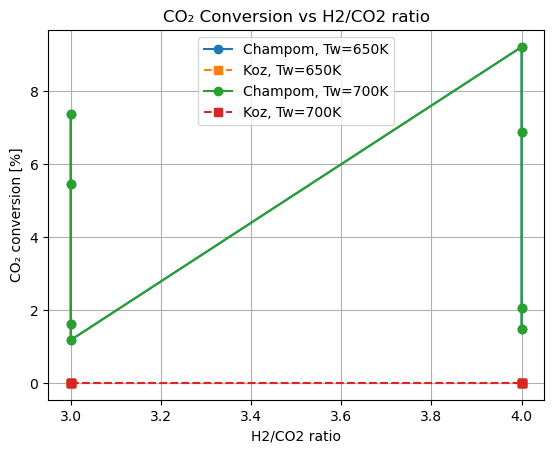

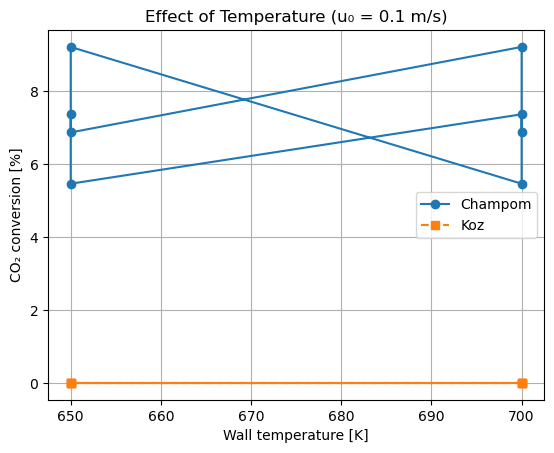

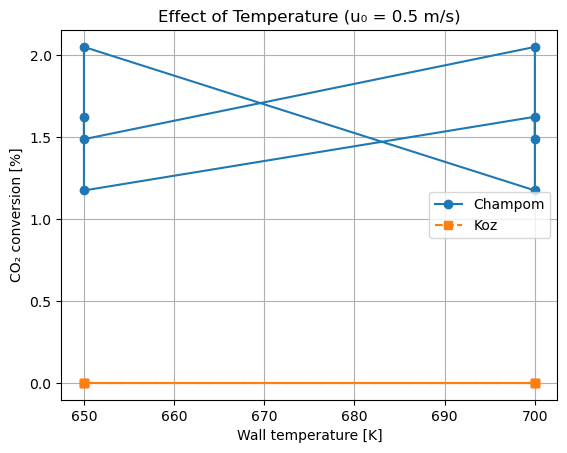

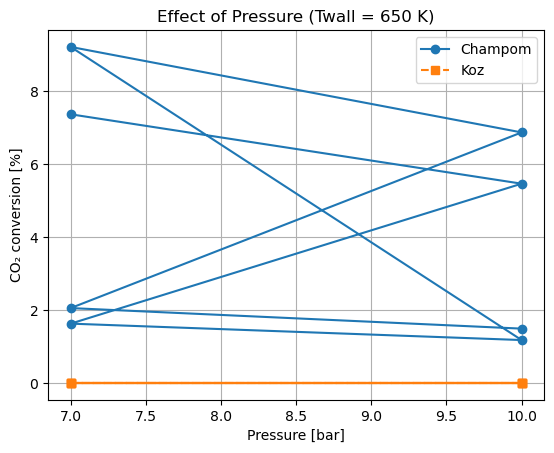

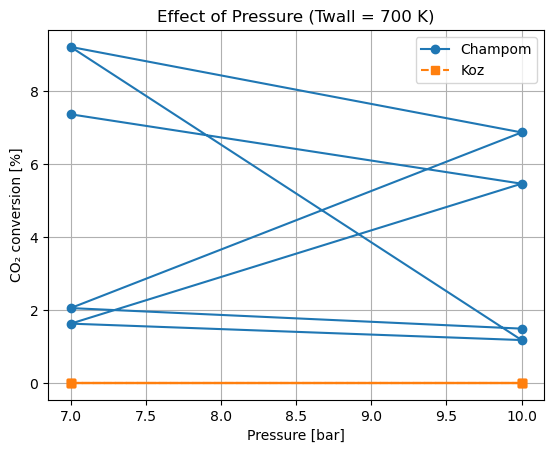

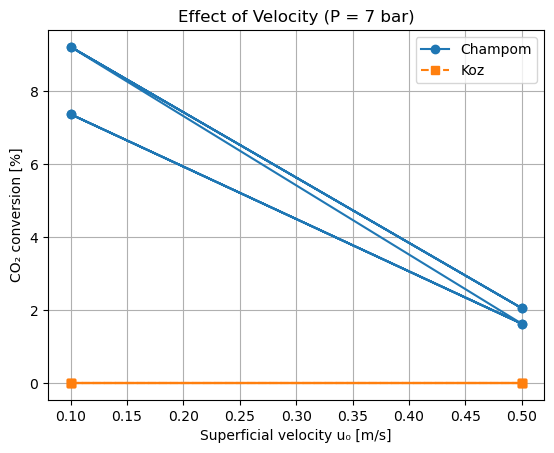

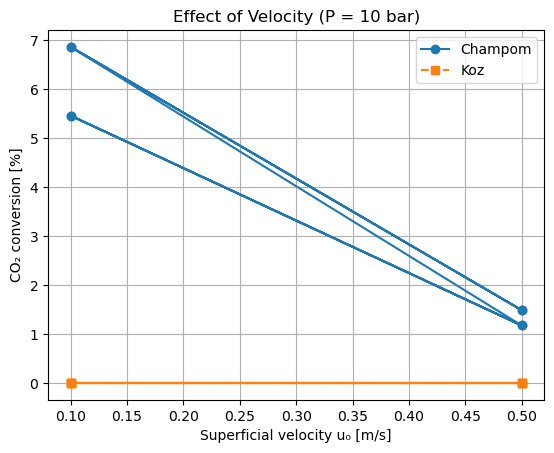

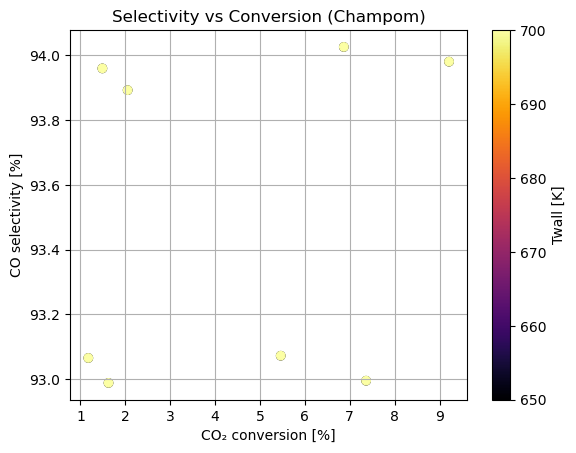

In [10]:
# ============================================================
# FULL STEADY-STATE REACTOR + PARAMETRIC + MULTI-KINETICS
# ============================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt
from fipy.tools import numerix
import pandas as pd
from fipy.terms import ImplicitSourceTerm


def safe(x):
    return numerix.maximum(x, 1e-8)

def safe_exp(x):
    return numerix.exp(numerix.clip(x, -100, 100))

def safe_div(numer, denom, eps=1e-12):
    return numer / numerix.maximum(denom, eps)

def radial_avg(Cvar, Nr, Nz):
    """Return radial average along reactor length (axis=0 is radial)."""
    return np.mean(Cvar.reshape(Nr, Nz), axis=0)

# -----------------------------
# Global constants
# -----------------------------
R = 8.314
rho_b = 2450
eps = 0.4
Dr, Dz = 1e-5, 1e-5
lambda_e = 0.8
dH = [-165e3, 41e3, -206e3]
Tin = 600
rhoCp = 1.5e6


species = ["H2", "CO2", "CH4", "H2O", "CO"]

nu = {
    "H2":  [-4, -1, -3],
    "CO2": [-1, -1,  0],
    "CH4": [ 1,  0,  1],
    "H2O": [ 2,  1,  1],
    "CO":  [ 0,  1, -1]
}


# ============================================================
# KINETIC MODELS
# ============================================================

def champom_kinetics(p, T, k):
    T = numerix.clip(T, 300, 2000)

    kco2  = k["k0co2"]  * safe_exp(-k["eaco2"] / (R*T))
    krwgs = k["k0rwgs"] * safe_exp(-k["earwgs"] / (R*T))
    kco   = k["k0co"]   * safe_exp(-k["eaco"] / (R*T))

    Keq = 137* T**(-3.998) * safe_exp(158700/(R*T))

    Kco  = k["kads0co"]  * safe_exp(k["deltahco"]  / (R*T))
    Kh2  = k["kads0h2"]  * safe_exp(k["deltahh2"]  / (R*T))
    Kh2o = k["kads0h2o"] * safe_exp(k["deltahh2o"] / (R*T))
    Kco2 = k["kads0co2"] * safe_exp(k["deltahco2"] / (R*T))

    denom = 1 + Kh2 * p["H2"] + Kco2 * p["CO2"] + Kh2o * p["H2O"] + Kco * p["CO"]

    driving = safe_div(1 - (p["CH4"] * p["H2O"]**2) / (p["CO2"] * p["H2"]**4 * Keq), 1)
    driving = numerix.clip(driving, 0, 1)

    r1 = kco2 * Kh2 * Kco2 * p["H2"] * p["CO2"] * driving / numerix.maximum(denom**2, 1e-12)
    r2 = krwgs * p["CO2"] / numerix.maximum(denom, 1e-12)
    r3   = kco * p["CO"] * p["H2"] / numerix.maximum(denom**2, 1e-12)
    
    return [r1, r2, r3]

def koz_kinetics(p, T, k):
    T = numerix.clip(T, 300, 2000)

    kf = k["k0"] * safe_exp(-k["Ea"] / (R*T))
    Keq = 137 * T**(-3.998) * safe_exp(158700 / (R*T))

    K_OH  = numerix.exp(k["Aoh"]  + k["Boh"] / T)
    K_H2  = numerix.exp(k["Ah2"]  + k["Bh2"] / T)
    K_mix = numerix.exp(k["Amix"] + k["Bmix"] / T)

    driving = safe_div(1 - (p["CH4"] * p["H2O"]**2)/(p["CO2"] * p["H2"]**4 * Keq),1)
    driving = numerix.clip(driving,0,1)

    num = kf * p["H2"]**0.5 * p["CO2"]**0.5 * driving
    den = (1 + K_OH*(p["H2O"] / p["H2"]**0.5) + K_H2*p["H2"]**0.5 + K_mix*p["CO2"]**0.5)**2

    return safe_div(num, den), 0.0, 0.0

def run_reactor(H2_CO2, Twall, u0, Pbar, kinetics, kin_params):

    # ---- geometry (radial only)
    Rr, Lz = 0.1, 1.0
    Nr, Nz = 100, 100
    mesh = CylindricalGrid2D(
        dr=Rr/Nr, dz=Lz/Nz, nr=Nr, nz=Nz
    )

    R = 8.314
    rho_b = 2450
    eps = 0.4
    Dr, Dz = 1e-5, 1e-5
    lambda_e = 0.8
    dH = [-165e3, 41e3, -206e3]
    Tin = 600
    rhoCp = 1.5e6

    dz = Lz / Nz
    dtau = dz / u0   # pseudo-time step

    # ---- inlet
    yCO2 = 1 / (1 + H2_CO2)
    yH2  = H2_CO2 * yCO2

    Cin = {
        "CO2": Pbar * 1e5 * yCO2 / (R * Tin),
        "H2":  Pbar * 1e5 * yH2  / (R * Tin),
        "CH4": 1e-12,
        "CO":  1e-12,
        "H2O": 1e-12
    }

    # ---- variables
    C = {sp: CellVariable(mesh=mesh, value=Cin[sp], hasOld=True)
         for sp in species}
    T = CellVariable(mesh=mesh, value=Tin, hasOld=True)

    # ---- BCs (radial only)
    for sp in species:
        C[sp].faceGrad.constrain(0, mesh.facesLeft)   # r=0 symmetry
        C[sp].faceGrad.constrain(0, mesh.facesRight)  # no mass flux

    T.faceGrad.constrain(0, mesh.facesLeft)
    T.constrain(Twall, mesh.facesRight)

    # ---- equations (no convection!)
    eqs = []
    for sp in species:

        p = {s: safe(C[s] * R * T / 1e5) for s in species}
        rates = kinetics(p, T, kin_params)
        Rsp = sum(nu[sp][i] * rates[i] for i in range(3))

        eq = (
            TransientTerm(var=C[sp])
            ==
            DiffusionTerm(coeff=eps * Dr, var=C[sp])
            + ImplicitSourceTerm(
                coeff=rho_b * Rsp / (C[sp] + 1e-12),
                var=C[sp]
            )
        )
        eqs.append(eq)

    Qrxn = sum(-dH[i] * rates[i] for i in range(3))

    energy = (
        TransientTerm(coeff=rhoCp, var=T)
        ==
        DiffusionTerm(coeff=lambda_e, var=T)
        + ImplicitSourceTerm(
            coeff=rho_b * Qrxn / (T + 1e-6),
            var=T
        )
    )

    # ==========================================================
    # AXIAL MARCHING
    # ==========================================================
    for k in range(Nz):

        for sp in species:
            C[sp].updateOld()
        T.updateOld()

        for eq in eqs:
            eq.solve(dt=dtau)

        energy.solve(dt=dtau)

        if k % 50 == 0:
            print(f"z = {k*dz:6.3f} m | Tmax = {T.value.max():7.1f} K")

    # ==========================================================
    # OUTLET EXTRACTION (FIXED)
    # ==========================================================
    # Final field already represents z = L
    # Take radial average (or centerline if you prefer)

    CO2_out = C["CO2"].value[-Nr:].mean()
    CH4_out = C["CH4"].value[-Nr:].mean()
    
    X = (Cin["CO2"] - CO2_out) / Cin["CO2"]
    S = CH4_out / (Cin["CO2"] - CO2_out + 1e-12)
    
    T_centerline = T.value.reshape(Nz, Nr)[:, 0]
    
    return X, S, T_centerline

# ============================================================
# PARAMETERS
# ============================================================

# ---- Champom kinetics ----
kin_champom = dict(
    k0co2=1900000, eaco2=110000,
    k0rwgs=29666.66667, earwgs=97100,
    k0co=3716666.667, eaco=97300,
    kads0co=0.00239, deltahco=40600,
    kads0h2=0.000052, deltahh2=52000,
    kads0h2o=0.609, deltahh2o=14500,
    kads0co2=1.07, deltahco2=9720
)

kin_koz = dict(
    k0=3.46e-5,
    Ea=77500,
    Aoh=0.5, Boh=-2694.25,
    Ah2=0.44, Bh2=745.73,
    Amix=0.88, Bmix=1202.79
)

ratios = [3, 4]
Twalls = [650, 700]
vels = [0.1, 0.5]
pressures = [7, 10]

# ============================================================
# PARAMETRIC SWEEP
# ============================================================

results = []

case = 0
total = len(ratios) * len(Twalls) * len(vels) * len(pressures)

for r in ratios:
    for Tw in Twalls:
        for u in vels:
            for P in pressures:
                case += 1
                print(f"▶ Case {case} / {total} | H2/CO2={r}, T={Tw}, u={u}, P={P}")

                Xc, Sc, Tc = run_reactor(r, Tw, u, P,
                                     champom_kinetics, kin_champom)
                Xk, Sk, Tk = run_reactor(r, Tw, u, P,
                                     koz_kinetics, kin_koz)
                results.append([r, Tw, u, P, Xc, Sc, Xk, Sk])

results = pd.DataFrame(
    results,
    columns=["H2_CO2", "Twall", "u0", "P",
             "X_champom", "S_champom", "X_Koz", "S_Koz"]
)

results

# ============================================================
# PLOTS
# ============================================================

# Convert conversion and selectivity to percent
results["X_ch_pct"] = results["X_champom"] * 100
results["X_koz_pct"] = results["X_Koz"] * 100
results["S_ch_pct"] = results["S_champom"] * 100
results["S_koz_pct"] = results["S_Koz"] * 100

# --- CO2 Conversion vs H2/CO2 ratio ---
plt.figure()
for Tw in Twalls:
    sub = results[results.Twall == Tw]
    plt.plot(sub.H2_CO2, sub.X_ch_pct, "o-", label=f"Champom, Tw={Tw}K")
    plt.plot(sub.H2_CO2, sub.X_koz_pct, "s--", label=f"Koz, Tw={Tw}K")
plt.xlabel("H2/CO2 ratio")
plt.ylabel("CO₂ conversion [%]")
plt.title("CO₂ Conversion vs H2/CO2 ratio")
plt.legend()
plt.grid(True)
plt.show()

# --- CO2 Conversion vs Wall Temperature ---
for u in results.u0.unique():
    sub = results[results.u0 == u]
    plt.figure()
    plt.plot(sub.Twall, sub.X_ch_pct, 'o-', label="Champom")
    plt.plot(sub.Twall, sub.X_koz_pct, 's--', label="Koz")
    plt.xlabel("Wall temperature [K]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Temperature (u₀ = {u} m/s)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- CO2 Conversion vs Pressure ---
for Tw in results.Twall.unique():
    sub = results[results.Twall == Tw]
    plt.figure()
    plt.plot(sub.P, sub.X_ch_pct, 'o-', label="Champom")
    plt.plot(sub.P, sub.X_koz_pct, 's--', label="Koz")
    plt.xlabel("Pressure [bar]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Pressure (Twall = {Tw} K)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- CO2 Conversion vs Velocity ---
for P in results.P.unique():
    sub = results[results.P == P]
    plt.figure()
    plt.plot(sub.u0, sub.X_ch_pct, 'o-', label="Champom")
    plt.plot(sub.u0, sub.X_koz_pct, 's--', label="Koz")
    plt.xlabel("Superficial velocity u₀ [m/s]")
    plt.ylabel("CO₂ conversion [%]")
    plt.title(f"Effect of Velocity (P = {P} bar)")
    plt.legend()
    plt.grid(True)
    plt.show()

# --- Selectivity vs Conversion ---
plt.figure()
plt.scatter(results.X_ch_pct, results.S_ch_pct, c=results.Twall,
            cmap="inferno", label="Champom")
plt.colorbar(label="Twall [K]")
plt.xlabel("CO₂ conversion [%]")
plt.ylabel("CO selectivity [%]")
plt.title("Selectivity vs Conversion (Champom)")
plt.grid(True)

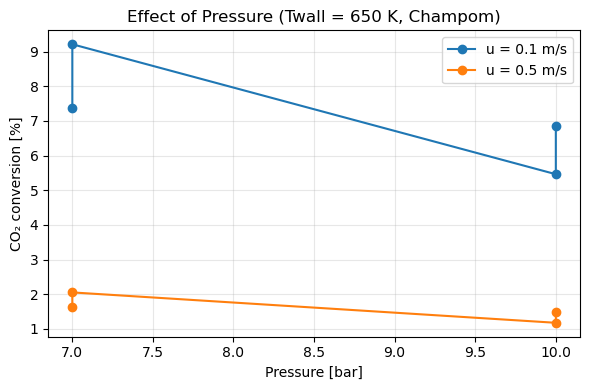

In [11]:
plt.figure(figsize=(6,4))

for u in results.u0.unique():
    sub = results[
        (results.Twall == 650) &
        (results.u0 == u)
    ].sort_values("P")

    plt.plot(
        sub.P,
        sub.X_ch_pct,
        marker="o",
        label=f"u = {u} m/s"
    )

plt.xlabel("Pressure [bar]")
plt.ylabel("CO₂ conversion [%]")
plt.title("Effect of Pressure (Twall = 650 K, Champom)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


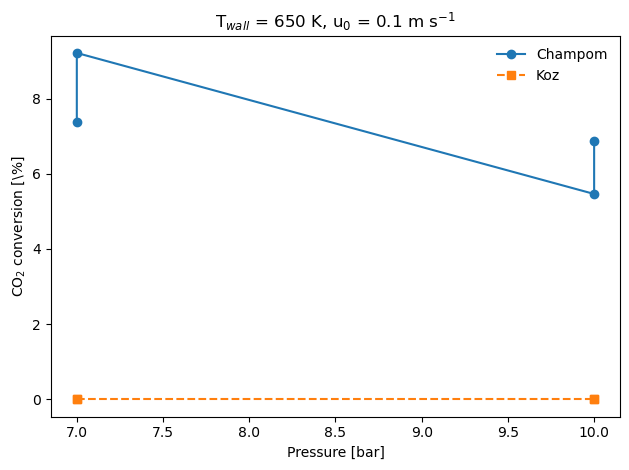

In [15]:
Tw = 650
u = 0.1

sub = results[
    (results.Twall == Tw) &
    (results.u0 == u)
].sort_values("P")

journal_plot(
    sub.P,
    {
        "Champom": (sub.P, sub.X_ch_pct, "o-"),
        "Koz":     (sub.P, sub.X_koz_pct, "s--")
    },
    xlabel="Pressure [bar]",
    ylabel="CO$_2$ conversion [\\%]",
    title=f"T$_{{wall}}$ = {Tw} K, u$_0$ = {u} m s$^{{-1}}$"
)


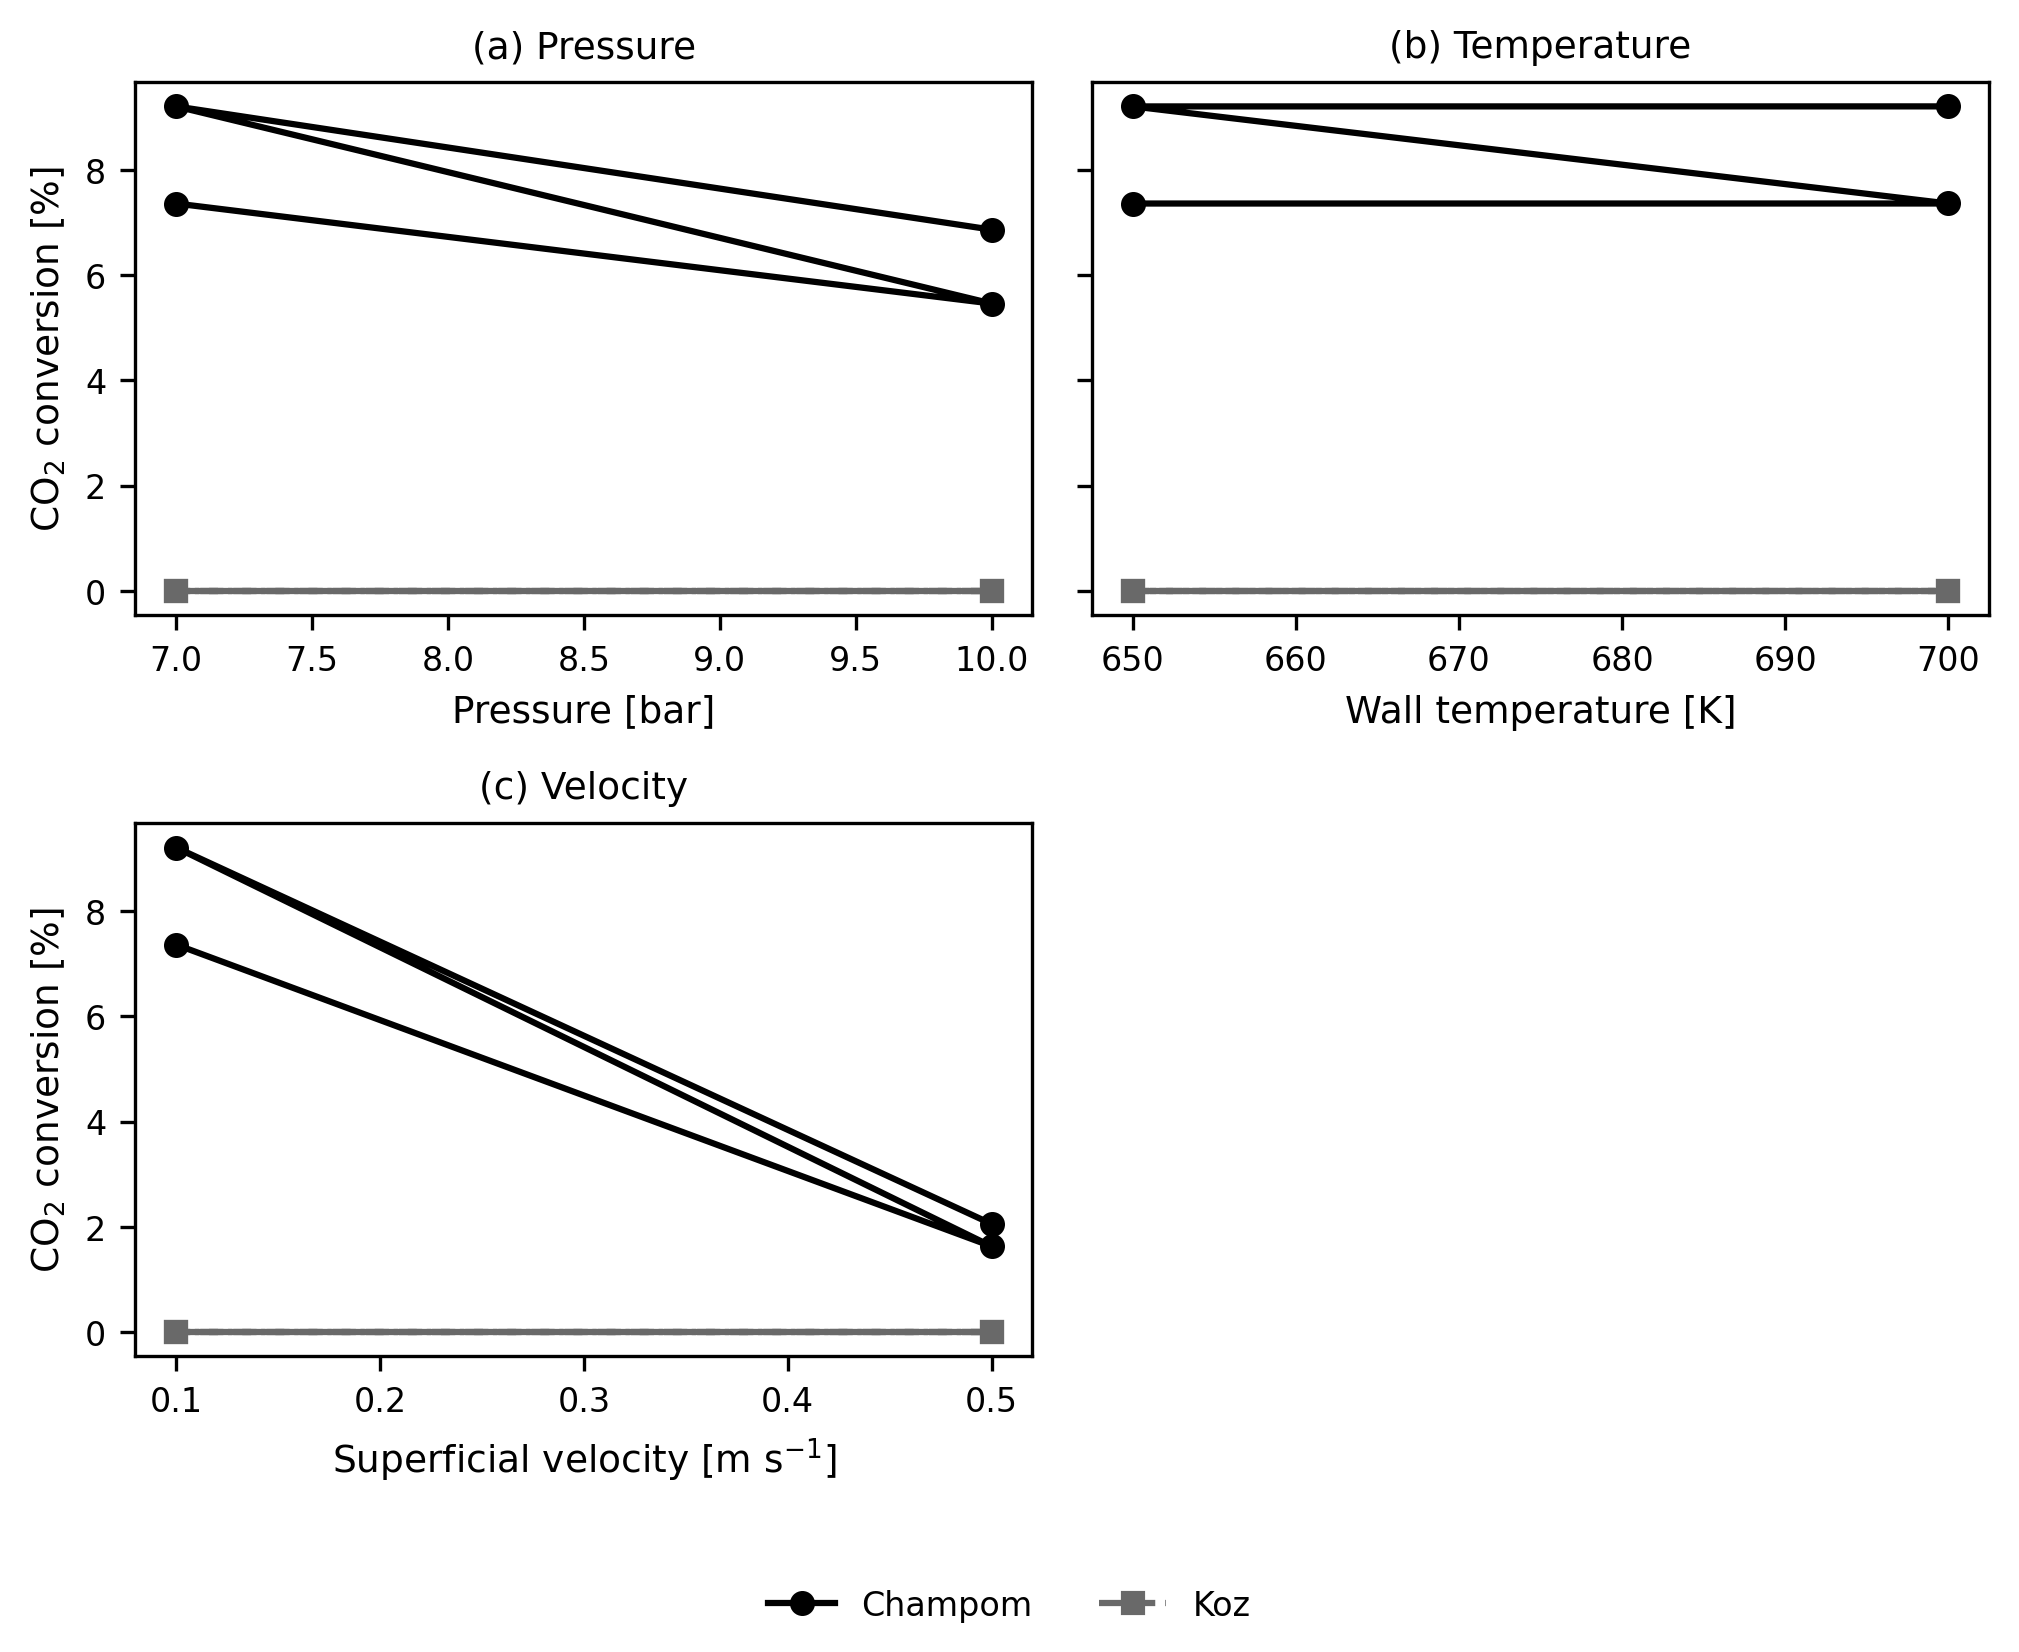

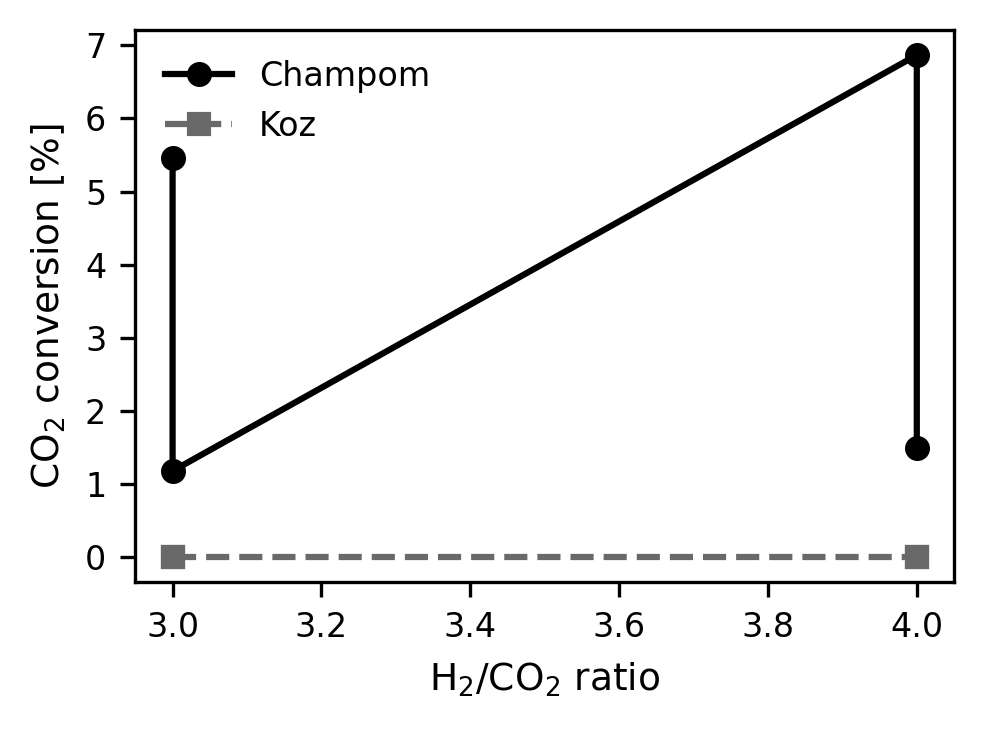

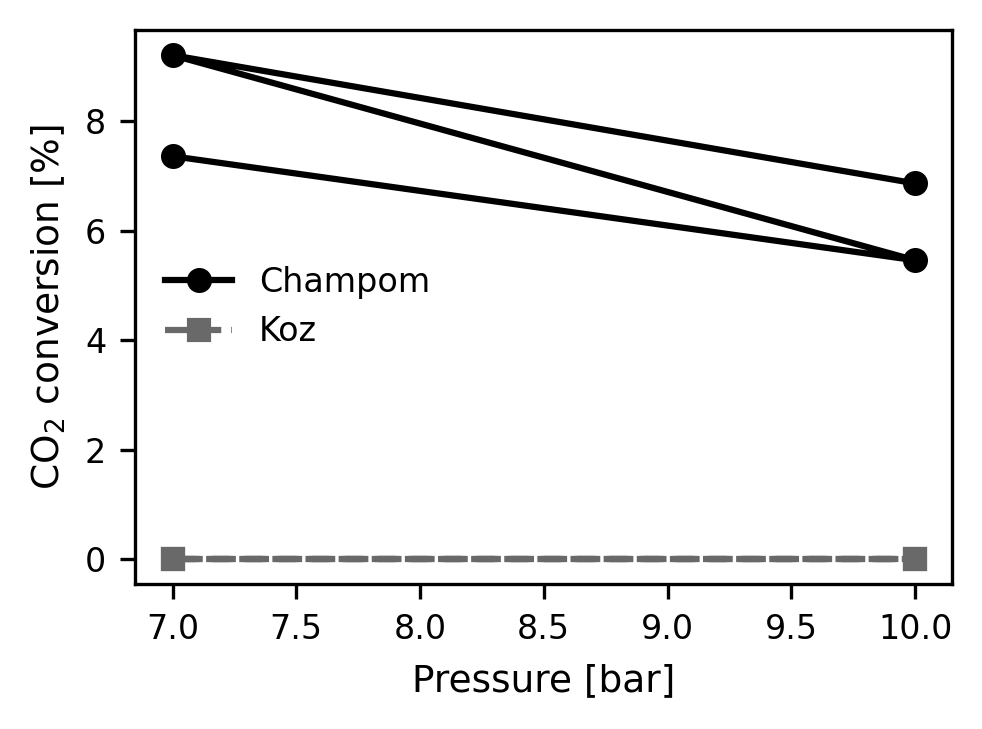

In [17]:
# ============================================================
# JOURNAL-READY STYLE (Energy / CES)
# ============================================================

import matplotlib.pyplot as plt

COLORS = {
    "Champom": "black",
    "Koz": "dimgray"
}

MARKERS = {
    "Champom": "o",
    "Koz": "s"
}

LINESTYLES = {
    "Champom": "-",
    "Koz": "--"
}

plt.rcParams.update({
    "figure.figsize": (6.8, 5.5),   # double-column
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "lines.markersize": 5,
    "axes.grid": False,
    "figure.dpi": 300
})
def plot_sweep(ax, x, y, label):
    ax.plot(
        x,
        y,
        marker=MARKERS[label],
        linestyle=LINESTYLES[label],
        color=COLORS[label],
        label=label
    )
fig, axes = plt.subplots(2, 2, sharey=True)
axes = axes.flatten()

# (a) Pressure
sub = results[(results.Twall == 650) & (results.u0 == 0.1)]
plot_sweep(axes[0], sub.P, sub.X_ch_pct, "Champom")
plot_sweep(axes[0], sub.P, sub.X_koz_pct, "Koz")
axes[0].set_xlabel("Pressure [bar]")
axes[0].set_ylabel("CO$_2$ conversion [%]")
axes[0].set_title("(a) Pressure")

# (b) Wall temperature
sub = results[(results.P == 7) & (results.u0 == 0.1)]
plot_sweep(axes[1], sub.Twall, sub.X_ch_pct, "Champom")
plot_sweep(axes[1], sub.Twall, sub.X_koz_pct, "Koz")
axes[1].set_xlabel("Wall temperature [K]")
axes[1].set_title("(b) Temperature")

# (c) Velocity
sub = results[(results.Twall == 650) & (results.P == 7)]
plot_sweep(axes[2], sub.u0, sub.X_ch_pct, "Champom")
plot_sweep(axes[2], sub.u0, sub.X_koz_pct, "Koz")
axes[2].set_xlabel("Superficial velocity [m s$^{-1}$]")
axes[2].set_ylabel("CO$_2$ conversion [%]")
axes[2].set_title("(c) Velocity")

# Remove unused panel
fig.delaxes(axes[3])

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()
plt.figure(figsize=(3.35, 2.5))  # single-column

sub = results[(results.Twall == 700) & (results.P == 10)]

plot_sweep(plt.gca(), sub.H2_CO2, sub.X_ch_pct, "Champom")
plot_sweep(plt.gca(), sub.H2_CO2, sub.X_koz_pct, "Koz")

plt.xlabel("H$_2$/CO$_2$ ratio")
plt.ylabel("CO$_2$ conversion [%]")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
def auto_parametric_plot(xvar, fixed, xlabel):
    plt.figure(figsize=(3.35, 2.5))

    sub = results.copy()
    for k, v in fixed.items():
        sub = sub[sub[k] == v]

    plot_sweep(plt.gca(), sub[xvar], sub.X_ch_pct, "Champom")
    plot_sweep(plt.gca(), sub[xvar], sub.X_koz_pct, "Koz")

    plt.xlabel(xlabel)
    plt.ylabel("CO$_2$ conversion [%]")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()
auto_parametric_plot(
    xvar="P",
    fixed={"Twall": 650, "u0": 0.1},
    xlabel="Pressure [bar]"
)


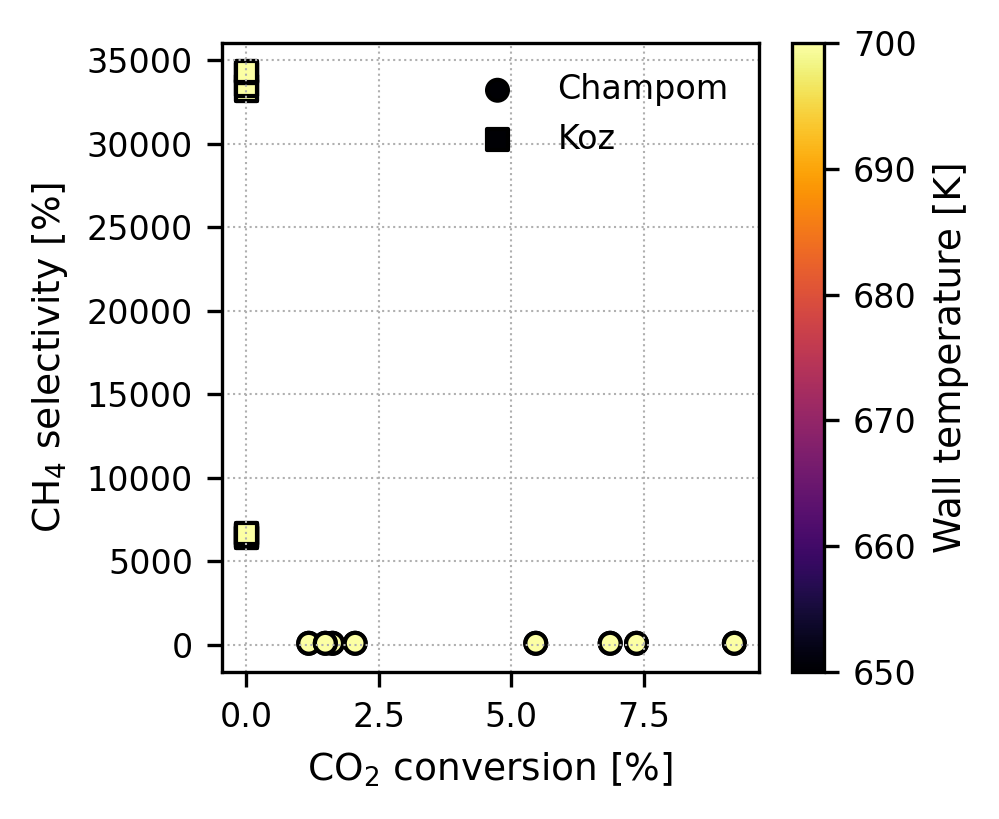

In [18]:
plt.figure(figsize=(3.35, 2.8))

plt.scatter(
    results.X_ch_pct,
    results.S_ch_pct,
    c=results.Twall,
    cmap="inferno",
    marker="o",
    edgecolor="black",
    label="Champom"
)

plt.scatter(
    results.X_koz_pct,
    results.S_koz_pct,
    c=results.Twall,
    cmap="inferno",
    marker="s",
    edgecolor="black",
    label="Koz"
)

cbar = plt.colorbar()
cbar.set_label("Wall temperature [K]")

plt.xlabel("CO$_2$ conversion [%]")
plt.ylabel("CH$_4$ selectivity [%]")

plt.legend(frameon=False)
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()


C:\Users\pingu\anaconda3\Lib\site-packages\fipy\terms\term.py:195: UserWarning: sweep() or solve() are likely to produce erroneous results when `var` does not contain floats.
  solver = self._prepareLinearSystem(var, solver, boundaryConditions, dt)
C:\Users\pingu\anaconda3\Lib\site-packages\fipy\terms\term.py:123: UserWarning: sweep() or solve() are likely to produce erroneous results when `var` does not contain floats.
  self._checkVar(var)


z =  0.000 m | Tmax =   604.0 K
z =  0.500 m | Tmax =   629.0 K
z =  0.000 m | Tmax =   609.0 K
z =  0.500 m | Tmax =   670.0 K


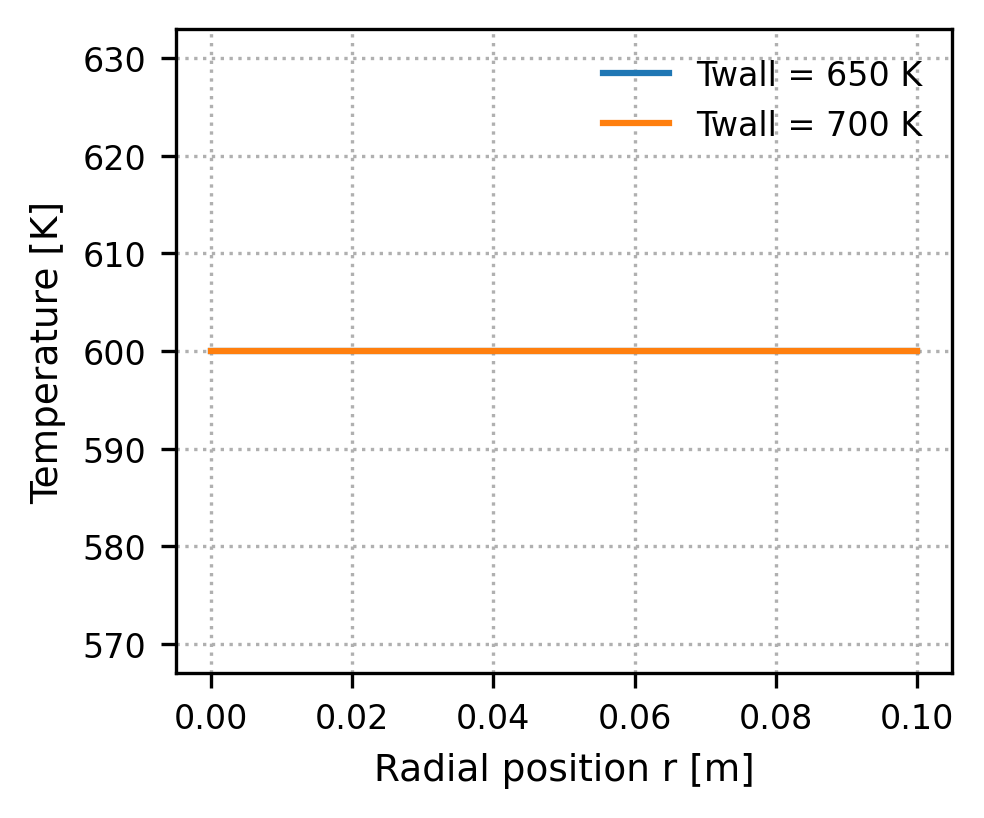

In [20]:
def radial_profile(T, Nr):
    """Return radial temperature at outlet."""
    return T.value[-Nr:]
r = np.linspace(0, Rr, Nr)

plt.figure(figsize=(3.35, 2.8))

for Tw in [650, 700]:
    _, _, Tfield = run_reactor(
        H2_CO2=3,
        Twall=Tw,
        u0=0.1,
        Pbar=7,
        kinetics=champom_kinetics,
        kin_params=kin_champom
    )

    plt.plot(
        r,
        Tfield[-Nr:],  # outlet radial slice
        label=f"Twall = {Tw} K",
        linewidth=1.5
    )

plt.xlabel("Radial position r [m]")
plt.ylabel("Temperature [K]")
plt.legend(frameon=False)
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

▶ Case 1 / 16 | H2/CO2=3, T=650, u=0.1, P=7
z =  0.000 m | Tmax =   604.0 K
z =  0.500 m | Tmax =   629.0 K
z =  0.000 m | Tmax =   604.0 K
z =  0.500 m | Tmax =   629.0 K
▶ Case 2 / 16 | H2/CO2=3, T=650, u=0.1, P=10
z =  0.000 m | Tmax =   604.0 K
z =  0.500 m | Tmax =   629.0 K
z =  0.000 m | Tmax =   604.0 K
z =  0.500 m | Tmax =   629.0 K
▶ Case 3 / 16 | H2/CO2=3, T=650, u=0.5, P=7
z =  0.000 m | Tmax =   601.0 K
z =  0.500 m | Tmax =   602.0 K
z =  0.000 m | Tmax =   601.0 K
z =  0.500 m | Tmax =   602.0 K
▶ Case 4 / 16 | H2/CO2=3, T=650, u=0.5, P=10
z =  0.000 m | Tmax =   601.0 K
z =  0.500 m | Tmax =   602.0 K
z =  0.000 m | Tmax =   601.0 K
z =  0.500 m | Tmax =   602.0 K
▶ Case 5 / 16 | H2/CO2=3, T=700, u=0.1, P=7
z =  0.000 m | Tmax =   609.0 K
z =  0.500 m | Tmax =   670.0 K
z =  0.000 m | Tmax =   609.0 K
z =  0.500 m | Tmax =   670.0 K
▶ Case 6 / 16 | H2/CO2=3, T=700, u=0.1, P=10
z =  0.000 m | Tmax =   609.0 K
z =  0.500 m | Tmax =   670.0 K
z =  0.000 m | Tmax =   609.0

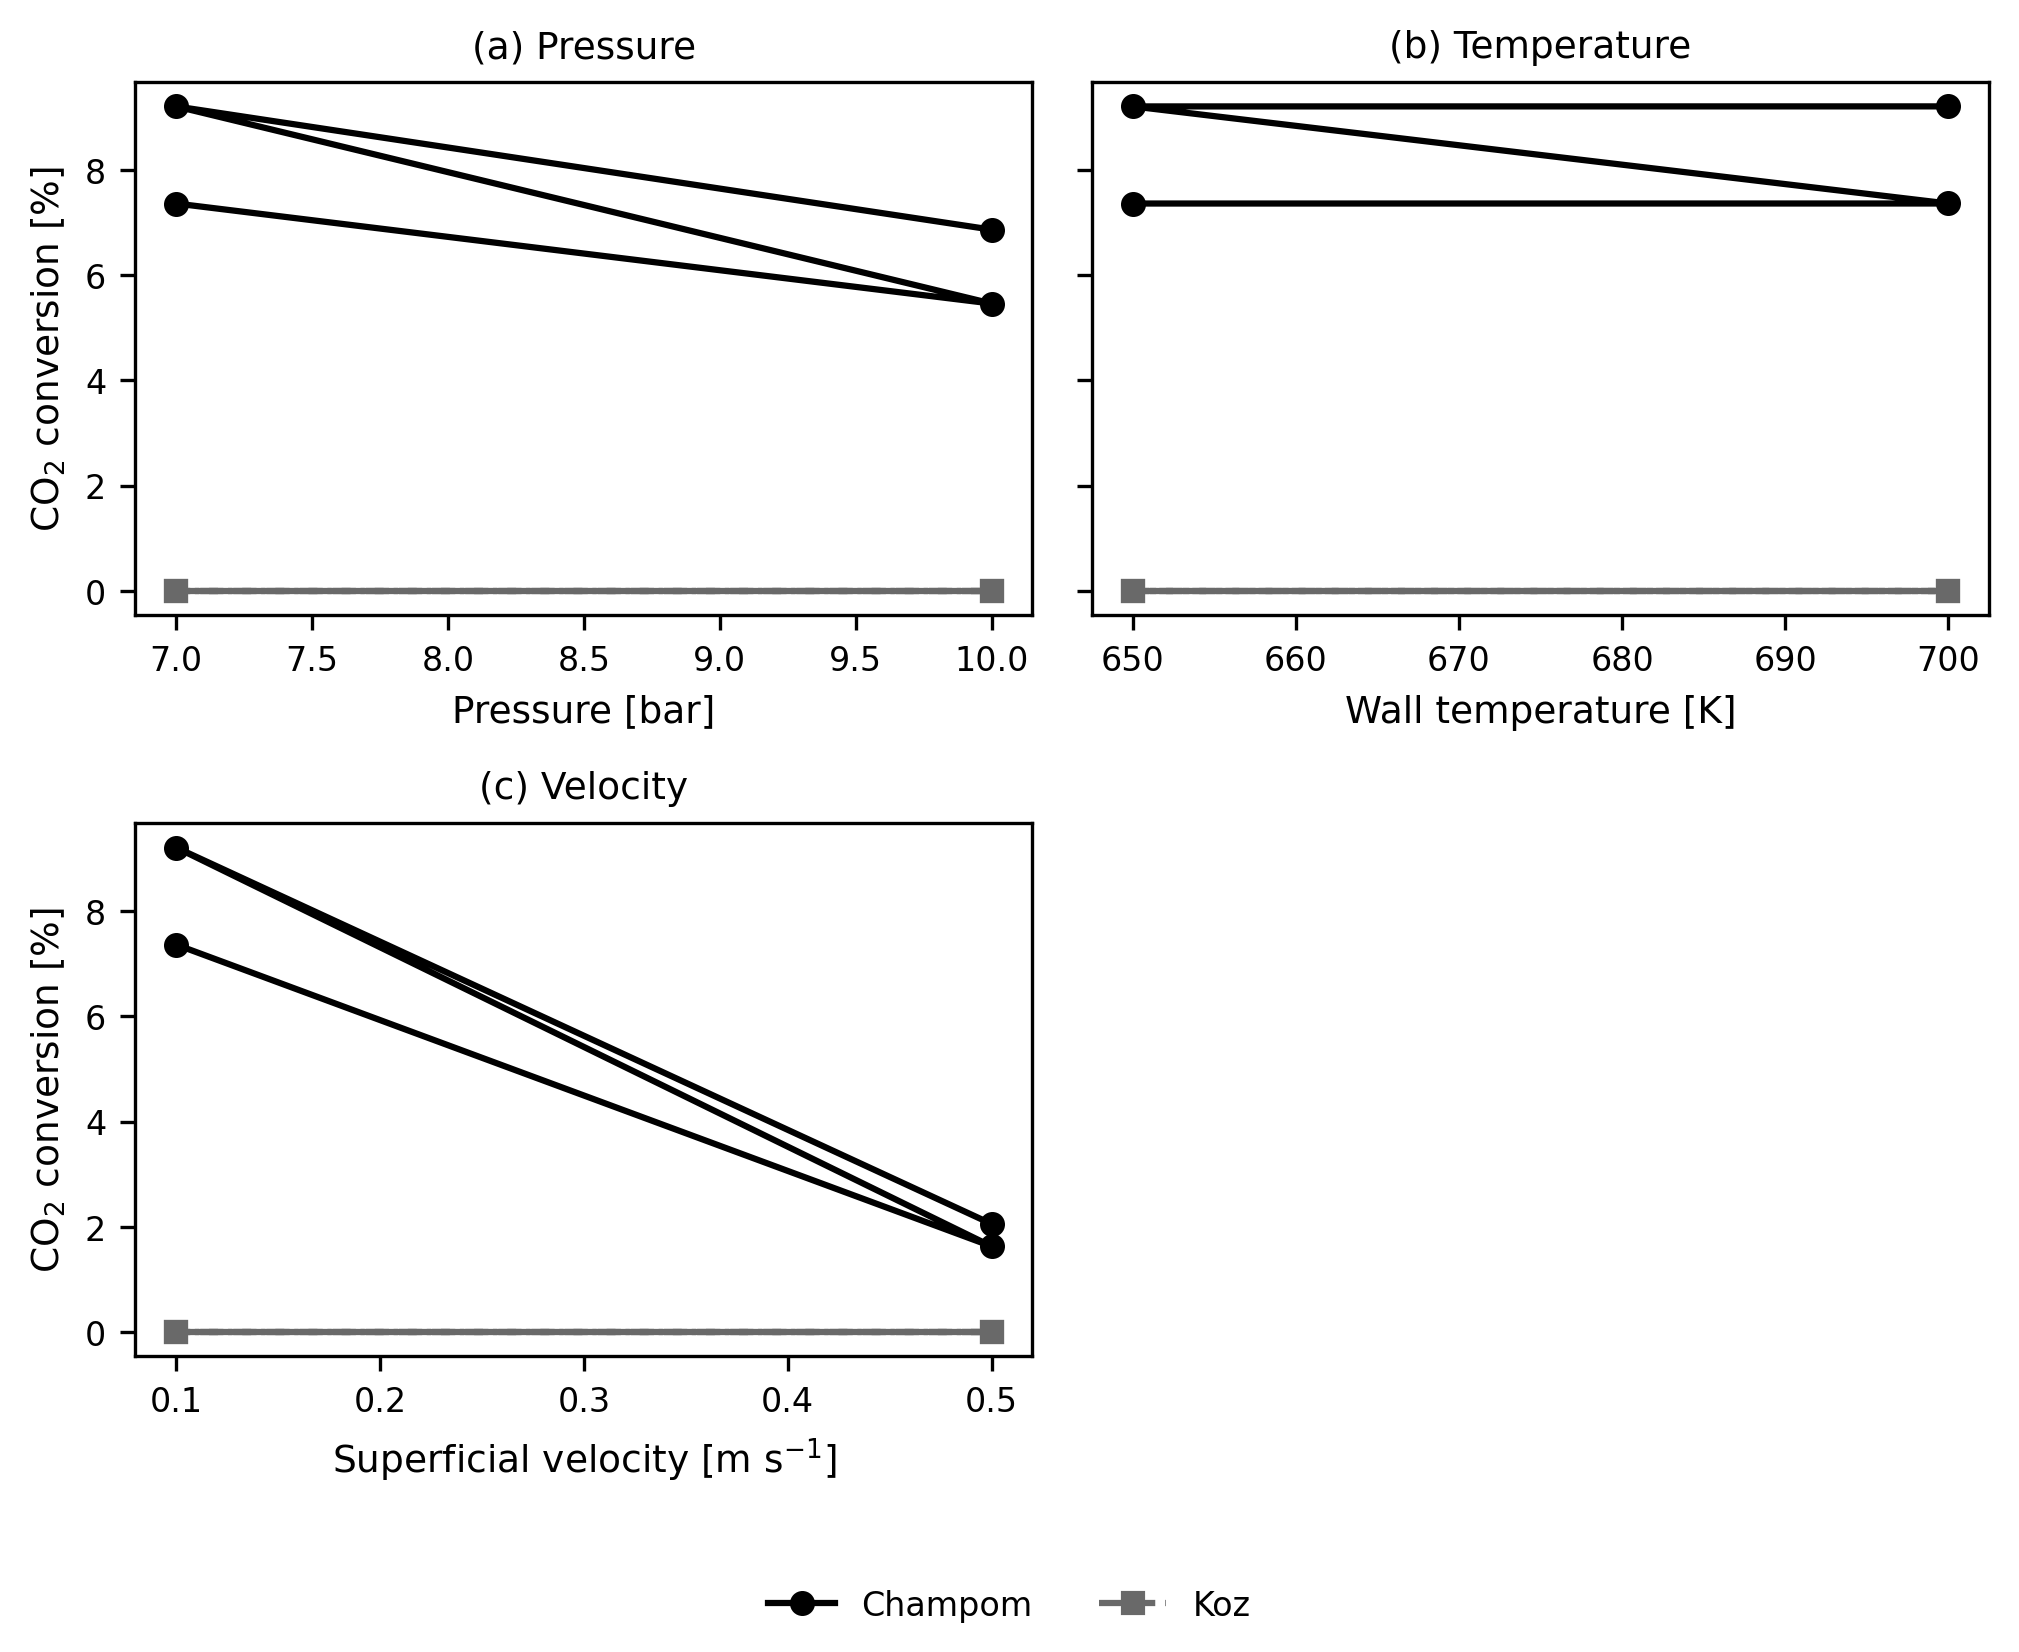

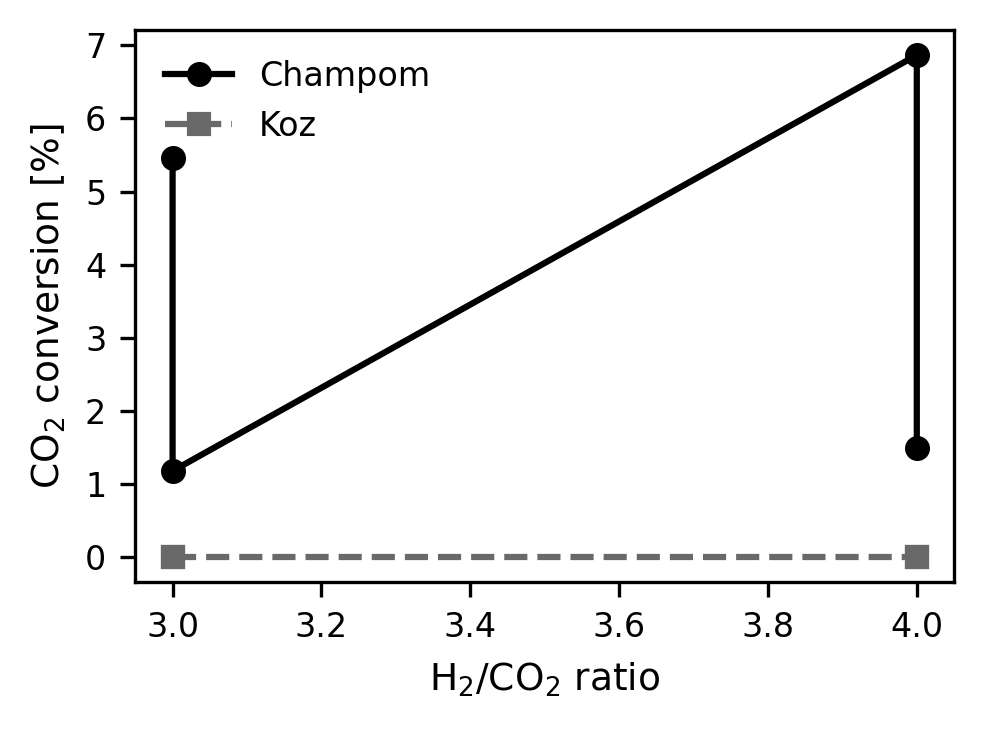

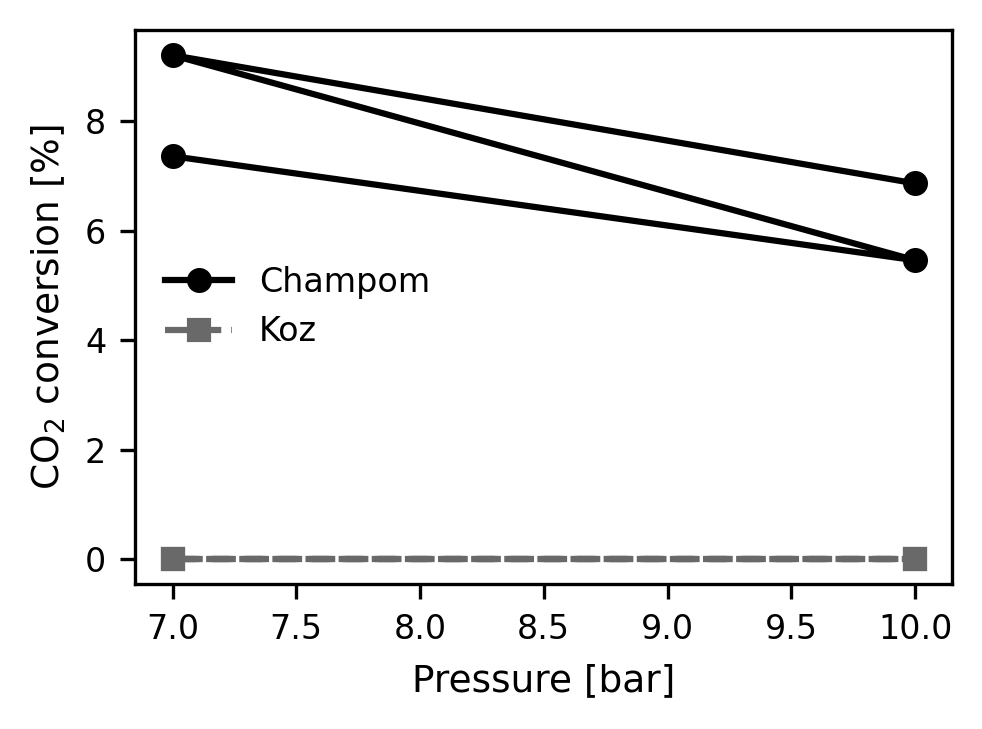

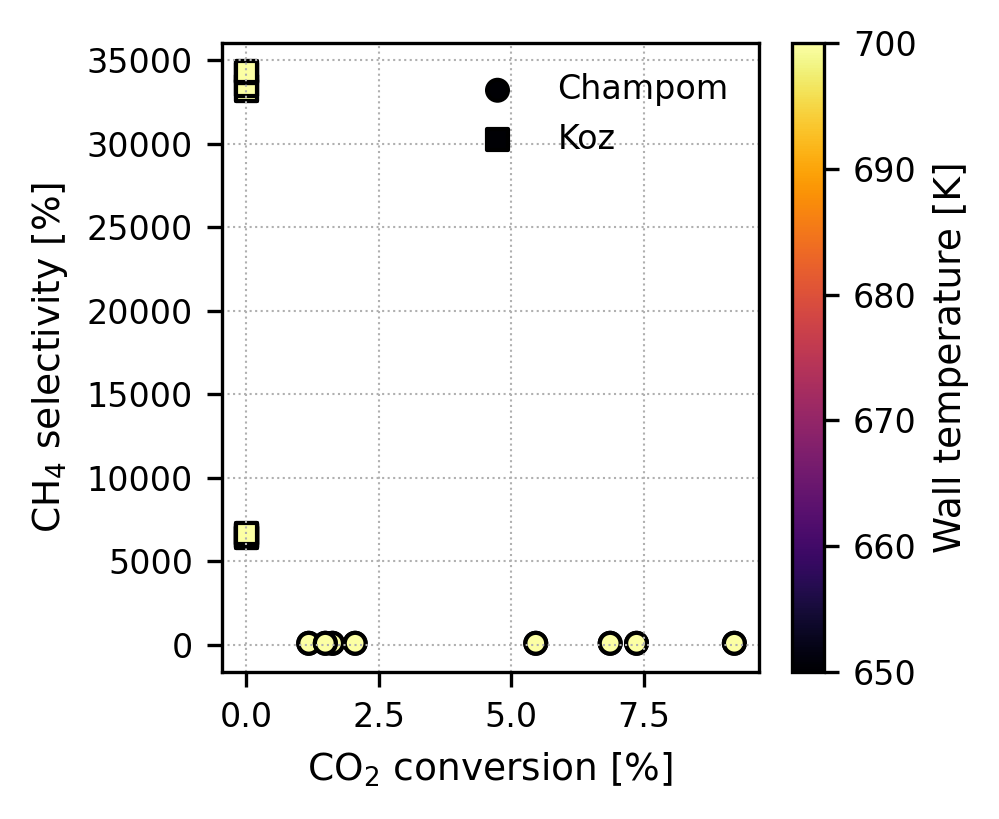

In [21]:
# ============================================================
# FULL STEADY-STATE REACTOR + PARAMETRIC + MULTI-KINETICS
# ============================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt
from fipy.tools import numerix
import pandas as pd
from fipy.terms import ImplicitSourceTerm


def safe(x):
    return numerix.maximum(x, 1e-8)

def safe_exp(x):
    return numerix.exp(numerix.clip(x, -100, 100))

def safe_div(numer, denom, eps=1e-12):
    return numer / numerix.maximum(denom, eps)

def radial_avg(Cvar, Nr, Nz):
    """Return radial average along reactor length (axis=0 is radial)."""
    return np.mean(Cvar.reshape(Nr, Nz), axis=0)

# -----------------------------
# Global constants
# -----------------------------
R = 8.314
rho_b = 2450
eps = 0.4
Dr, Dz = 1e-5, 1e-5
lambda_e = 0.8
dH = [-165e3, 41e3, -206e3]
Tin = 600
rhoCp = 1.5e6


species = ["H2", "CO2", "CH4", "H2O", "CO"]

nu = {
    "H2":  [-4, -1, -3],
    "CO2": [-1, -1,  0],
    "CH4": [ 1,  0,  1],
    "H2O": [ 2,  1,  1],
    "CO":  [ 0,  1, -1]
}


# ============================================================
# KINETIC MODELS
# ============================================================

def champom_kinetics(p, T, k):
    T = numerix.clip(T, 300, 2000)

    kco2  = k["k0co2"]  * safe_exp(-k["eaco2"] / (R*T))
    krwgs = k["k0rwgs"] * safe_exp(-k["earwgs"] / (R*T))
    kco   = k["k0co"]   * safe_exp(-k["eaco"] / (R*T))

    Keq = 137* T**(-3.998) * safe_exp(158700/(R*T))

    Kco  = k["kads0co"]  * safe_exp(k["deltahco"]  / (R*T))
    Kh2  = k["kads0h2"]  * safe_exp(k["deltahh2"]  / (R*T))
    Kh2o = k["kads0h2o"] * safe_exp(k["deltahh2o"] / (R*T))
    Kco2 = k["kads0co2"] * safe_exp(k["deltahco2"] / (R*T))

    denom = 1 + Kh2 * p["H2"] + Kco2 * p["CO2"] + Kh2o * p["H2O"] + Kco * p["CO"]

    driving = safe_div(1 - (p["CH4"] * p["H2O"]**2) / (p["CO2"] * p["H2"]**4 * Keq), 1)
    driving = numerix.clip(driving, 0, 1)

    r1 = kco2 * Kh2 * Kco2 * p["H2"] * p["CO2"] * driving / numerix.maximum(denom**2, 1e-12)
    r2 = krwgs * p["CO2"] / numerix.maximum(denom, 1e-12)
    r3   = kco * p["CO"] * p["H2"] / numerix.maximum(denom**2, 1e-12)
    
    return [r1, r2, r3]

def koz_kinetics(p, T, k):
    T = numerix.clip(T, 300, 2000)

    kf = k["k0"] * safe_exp(-k["Ea"] / (R*T))
    Keq = 137 * T**(-3.998) * safe_exp(158700 / (R*T))

    K_OH  = numerix.exp(k["Aoh"]  + k["Boh"] / T)
    K_H2  = numerix.exp(k["Ah2"]  + k["Bh2"] / T)
    K_mix = numerix.exp(k["Amix"] + k["Bmix"] / T)

    driving = safe_div(1 - (p["CH4"] * p["H2O"]**2)/(p["CO2"] * p["H2"]**4 * Keq),1)
    driving = numerix.clip(driving,0,1)

    num = kf * p["H2"]**0.5 * p["CO2"]**0.5 * driving
    den = (1 + K_OH*(p["H2O"] / p["H2"]**0.5) + K_H2*p["H2"]**0.5 + K_mix*p["CO2"]**0.5)**2

    return safe_div(num, den), 0.0, 0.0

def run_reactor(H2_CO2, Twall, u0, Pbar, kinetics, kin_params):

    # ---- geometry (radial only)
    Rr, Lz = 0.1, 1.0
    Nr, Nz = 100, 100
    mesh = CylindricalGrid2D(
        dr=Rr/Nr, dz=Lz/Nz, nr=Nr, nz=Nz
    )

    R = 8.314
    rho_b = 2450
    eps = 0.4
    Dr, Dz = 1e-5, 1e-5
    lambda_e = 0.8
    dH = [-165e3, 41e3, -206e3]
    Tin = 600
    rhoCp = 1.5e6

    dz = Lz / Nz
    dtau = dz / u0   # pseudo-time step

    # ---- inlet
    yCO2 = 1 / (1 + H2_CO2)
    yH2  = H2_CO2 * yCO2

    Cin = {
        "CO2": Pbar * 1e5 * yCO2 / (R * Tin),
        "H2":  Pbar * 1e5 * yH2  / (R * Tin),
        "CH4": 1e-12,
        "CO":  1e-12,
        "H2O": 1e-12
    }

    # ---- variables
    C = {sp: CellVariable(mesh=mesh, value=Cin[sp], hasOld=True)
         for sp in species}
    T = CellVariable(mesh=mesh, value=Tin, hasOld=True)

    # ---- BCs (radial only)
    for sp in species:
        C[sp].faceGrad.constrain(0, mesh.facesLeft)   # r=0 symmetry
        C[sp].faceGrad.constrain(0, mesh.facesRight)  # no mass flux

    T.faceGrad.constrain(0, mesh.facesLeft)
    T.constrain(Twall, mesh.facesRight)

    # ---- equations (no convection!)
    eqs = []
    for sp in species:

        p = {s: safe(C[s] * R * T / 1e5) for s in species}
        rates = kinetics(p, T, kin_params)
        Rsp = sum(nu[sp][i] * rates[i] for i in range(3))

        eq = (
            TransientTerm(var=C[sp])
            ==
            DiffusionTerm(coeff=eps * Dr, var=C[sp])
            + ImplicitSourceTerm(
                coeff=rho_b * Rsp / (C[sp] + 1e-12),
                var=C[sp]
            )
        )
        eqs.append(eq)

    Qrxn = sum(-dH[i] * rates[i] for i in range(3))

    energy = (
        TransientTerm(coeff=rhoCp, var=T)
        ==
        DiffusionTerm(coeff=lambda_e, var=T)
        + ImplicitSourceTerm(
            coeff=rho_b * Qrxn / (T + 1e-6),
            var=T
        )
    )

    # ==========================================================
    # AXIAL MARCHING
    # ==========================================================
    for k in range(Nz):

        for sp in species:
            C[sp].updateOld()
        T.updateOld()

        for eq in eqs:
            eq.solve(dt=dtau)

        energy.solve(dt=dtau)

        if k % 50 == 0:
            print(f"z = {k*dz:6.3f} m | Tmax = {T.value.max():7.1f} K")

    # ==========================================================
    # OUTLET EXTRACTION (FIXED)
    # ==========================================================
    # Final field already represents z = L
    # Take radial average (or centerline if you prefer)

    CO2_out = C["CO2"].value[-Nr:].mean()
    CH4_out = C["CH4"].value[-Nr:].mean()
    
    X = (Cin["CO2"] - CO2_out) / Cin["CO2"]
    S = CH4_out / (Cin["CO2"] - CO2_out + 1e-12)
    
    T_centerline = T.value.reshape(Nz, Nr)[:, 0]
    
    return X, S, T_centerline

# ============================================================
# PARAMETERS
# ============================================================

# ---- Champom kinetics ----
kin_champom = dict(
    k0co2=1900000, eaco2=110000,
    k0rwgs=29666.66667, earwgs=97100,
    k0co=3716666.667, eaco=97300,
    kads0co=0.00239, deltahco=40600,
    kads0h2=0.000052, deltahh2=52000,
    kads0h2o=0.609, deltahh2o=14500,
    kads0co2=1.07, deltahco2=9720
)

kin_koz = dict(
    k0=3.46e-5,
    Ea=77500,
    Aoh=0.5, Boh=-2694.25,
    Ah2=0.44, Bh2=745.73,
    Amix=0.88, Bmix=1202.79
)

ratios = [3, 4]
Twalls = [650, 700]
vels = [0.1, 0.5]
pressures = [7, 10]

# ============================================================
# PARAMETRIC SWEEP
# ============================================================

results = []

case = 0
total = len(ratios) * len(Twalls) * len(vels) * len(pressures)

for r in ratios:
    for Tw in Twalls:
        for u in vels:
            for P in pressures:
                case += 1
                print(f"▶ Case {case} / {total} | H2/CO2={r}, T={Tw}, u={u}, P={P}")

                Xc, Sc, Tc = run_reactor(r, Tw, u, P,
                                     champom_kinetics, kin_champom)
                Xk, Sk, Tk = run_reactor(r, Tw, u, P,
                                     koz_kinetics, kin_koz)
                results.append([r, Tw, u, P, Xc, Sc, Xk, Sk])

results = pd.DataFrame(
    results,
    columns=["H2_CO2", "Twall", "u0", "P",
             "X_champom", "S_champom", "X_Koz", "S_Koz"]
)

results

# ============================================================
# PLOTS
# ============================================================

# Convert conversion and selectivity to percent
results["X_ch_pct"] = results["X_champom"] * 100
results["X_koz_pct"] = results["X_Koz"] * 100
results["S_ch_pct"] = results["S_champom"] * 100
results["S_koz_pct"] = results["S_Koz"] * 100

# ============================================================
# JOURNAL-READY STYLE (Energy / CES)
# ============================================================

import matplotlib.pyplot as plt

COLORS = {
    "Champom": "black",
    "Koz": "dimgray"
}

MARKERS = {
    "Champom": "o",
    "Koz": "s"
}

LINESTYLES = {
    "Champom": "-",
    "Koz": "--"
}

plt.rcParams.update({
    "figure.figsize": (6.8, 5.5),   # double-column
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "lines.markersize": 5,
    "axes.grid": False,
    "figure.dpi": 300
})
def plot_sweep(ax, x, y, label):
    ax.plot(
        x,
        y,
        marker=MARKERS[label],
        linestyle=LINESTYLES[label],
        color=COLORS[label],
        label=label
    )
fig, axes = plt.subplots(2, 2, sharey=True)
axes = axes.flatten()

# (a) Pressure
sub = results[(results.Twall == 650) & (results.u0 == 0.1)]
plot_sweep(axes[0], sub.P, sub.X_ch_pct, "Champom")
plot_sweep(axes[0], sub.P, sub.X_koz_pct, "Koz")
axes[0].set_xlabel("Pressure [bar]")
axes[0].set_ylabel("CO$_2$ conversion [%]")
axes[0].set_title("(a) Pressure")

# (b) Wall temperature
sub = results[(results.P == 7) & (results.u0 == 0.1)]
plot_sweep(axes[1], sub.Twall, sub.X_ch_pct, "Champom")
plot_sweep(axes[1], sub.Twall, sub.X_koz_pct, "Koz")
axes[1].set_xlabel("Wall temperature [K]")
axes[1].set_title("(b) Temperature")

# (c) Velocity
sub = results[(results.Twall == 650) & (results.P == 7)]
plot_sweep(axes[2], sub.u0, sub.X_ch_pct, "Champom")
plot_sweep(axes[2], sub.u0, sub.X_koz_pct, "Koz")
axes[2].set_xlabel("Superficial velocity [m s$^{-1}$]")
axes[2].set_ylabel("CO$_2$ conversion [%]")
axes[2].set_title("(c) Velocity")

# Remove unused panel
fig.delaxes(axes[3])

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()
plt.figure(figsize=(3.35, 2.5))  # single-column

sub = results[(results.Twall == 700) & (results.P == 10)]

plot_sweep(plt.gca(), sub.H2_CO2, sub.X_ch_pct, "Champom")
plot_sweep(plt.gca(), sub.H2_CO2, sub.X_koz_pct, "Koz")

plt.xlabel("H$_2$/CO$_2$ ratio")
plt.ylabel("CO$_2$ conversion [%]")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
def auto_parametric_plot(xvar, fixed, xlabel):
    plt.figure(figsize=(3.35, 2.5))

    sub = results.copy()
    for k, v in fixed.items():
        sub = sub[sub[k] == v]

    plot_sweep(plt.gca(), sub[xvar], sub.X_ch_pct, "Champom")
    plot_sweep(plt.gca(), sub[xvar], sub.X_koz_pct, "Koz")

    plt.xlabel(xlabel)
    plt.ylabel("CO$_2$ conversion [%]")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()
auto_parametric_plot(
    xvar="P",
    fixed={"Twall": 650, "u0": 0.1},
    xlabel="Pressure [bar]"
)
plt.figure(figsize=(3.35, 2.8))

plt.scatter(
    results.X_ch_pct,
    results.S_ch_pct,
    c=results.Twall,
    cmap="inferno",
    marker="o",
    edgecolor="black",
    label="Champom"
)

plt.scatter(
    results.X_koz_pct,
    results.S_koz_pct,
    c=results.Twall,
    cmap="inferno",
    marker="s",
    edgecolor="black",
    label="Koz"
)

cbar = plt.colorbar()
cbar.set_label("Wall temperature [K]")

plt.xlabel("CO$_2$ conversion [%]")
plt.ylabel("CH$_4$ selectivity [%]")

plt.legend(frameon=False)
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

▶ Case 1 / 16 | H2/CO2=3, T=650, u=0.1, P=7
z =  0.000 m | Tmax =   604.0 K
z =  0.500 m | Tmax =   629.0 K
z =  0.000 m | Tmax =   604.0 K
z =  0.500 m | Tmax =   629.0 K
▶ Case 2 / 16 | H2/CO2=3, T=650, u=0.1, P=10
z =  0.000 m | Tmax =   604.0 K
z =  0.500 m | Tmax =   629.0 K
z =  0.000 m | Tmax =   604.0 K
z =  0.500 m | Tmax =   629.0 K
▶ Case 3 / 16 | H2/CO2=3, T=650, u=0.5, P=7
z =  0.000 m | Tmax =   601.0 K
z =  0.500 m | Tmax =   602.0 K
z =  0.000 m | Tmax =   601.0 K
z =  0.500 m | Tmax =   602.0 K
▶ Case 4 / 16 | H2/CO2=3, T=650, u=0.5, P=10
z =  0.000 m | Tmax =   601.0 K
z =  0.500 m | Tmax =   602.0 K
z =  0.000 m | Tmax =   601.0 K
z =  0.500 m | Tmax =   602.0 K
▶ Case 5 / 16 | H2/CO2=3, T=700, u=0.1, P=7
z =  0.000 m | Tmax =   609.0 K
z =  0.500 m | Tmax =   670.0 K
z =  0.000 m | Tmax =   609.0 K
z =  0.500 m | Tmax =   670.0 K
▶ Case 6 / 16 | H2/CO2=3, T=700, u=0.1, P=10
z =  0.000 m | Tmax =   609.0 K
z =  0.500 m | Tmax =   670.0 K
z =  0.000 m | Tmax =   609.0

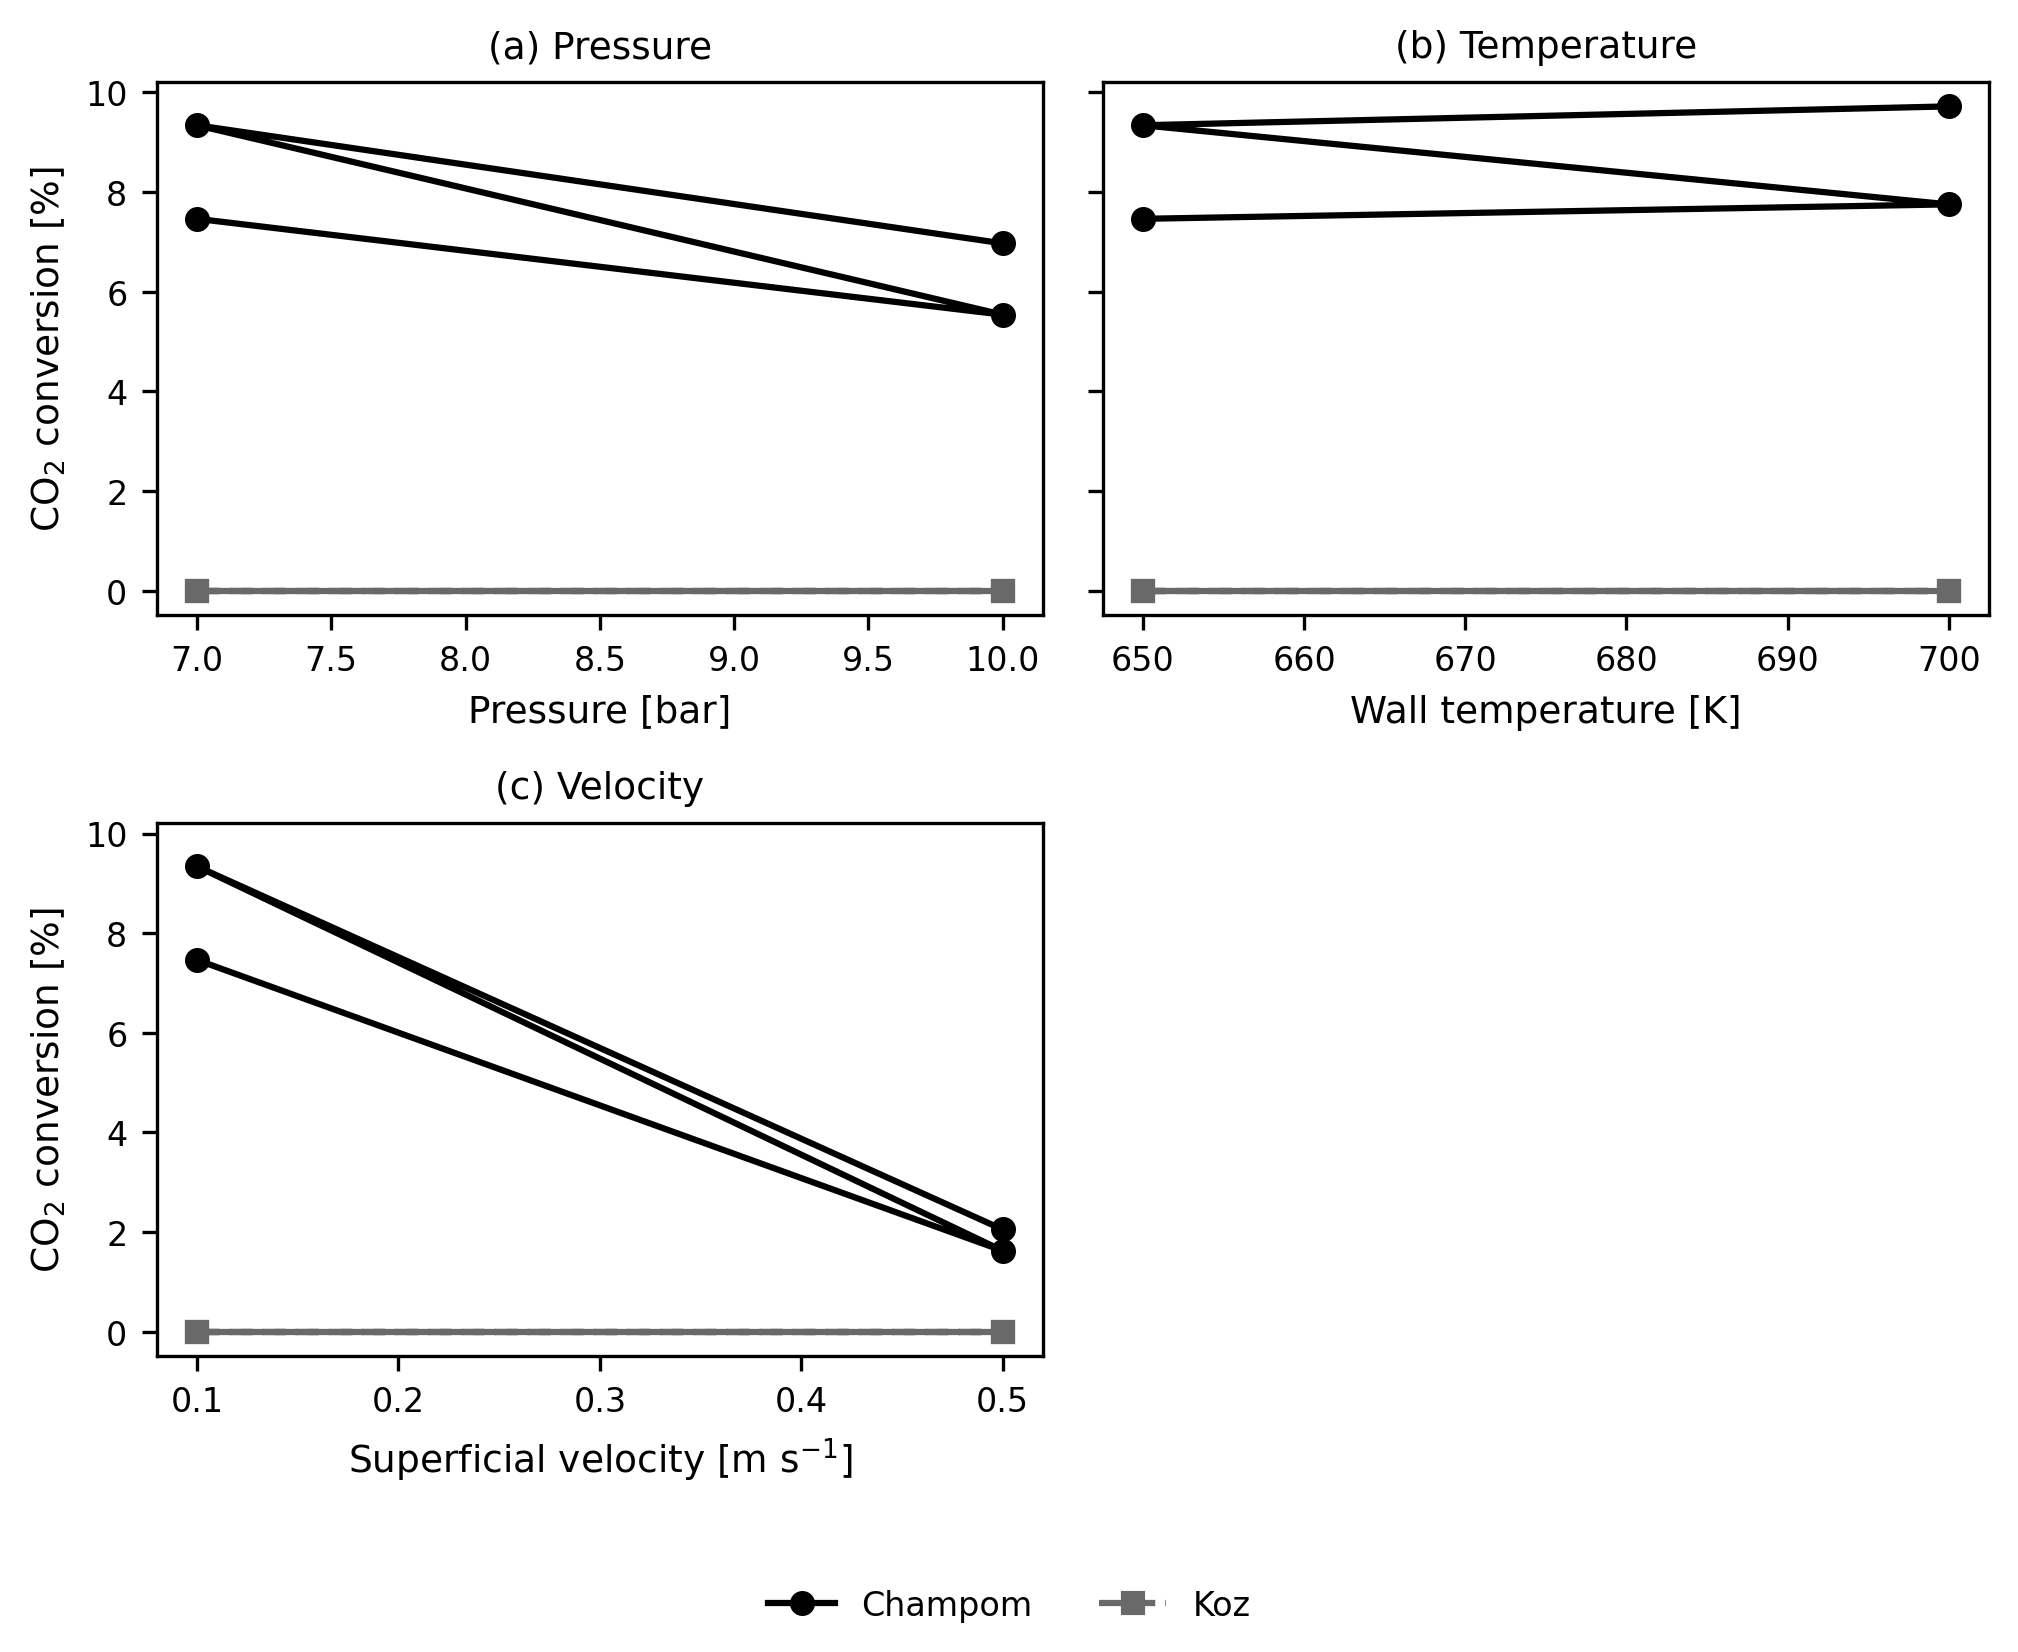

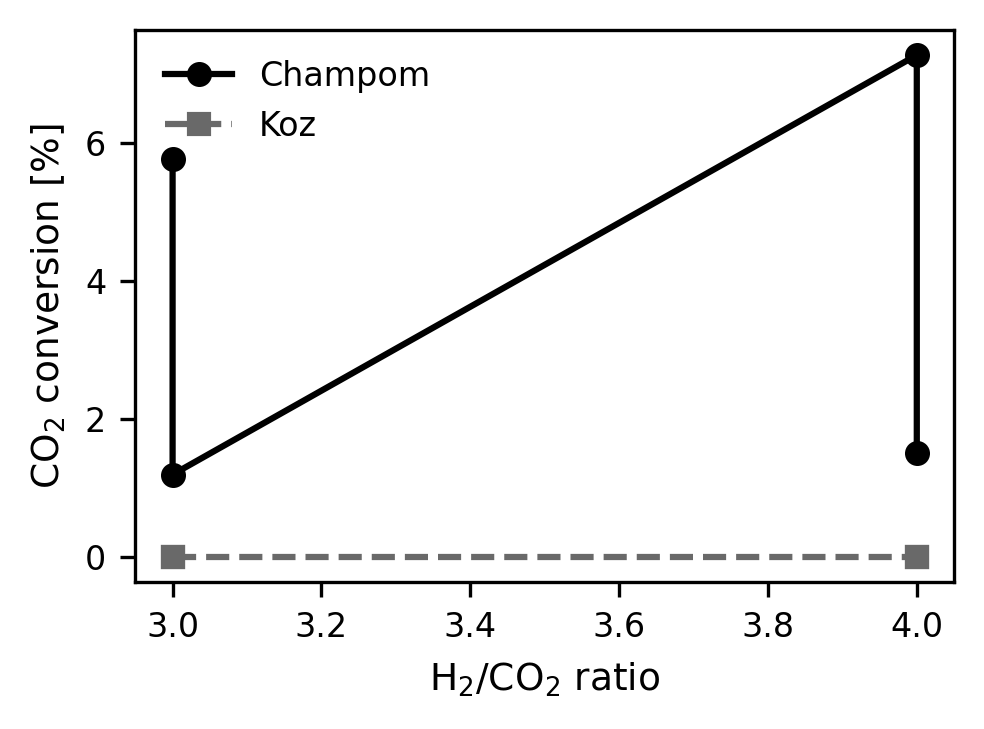

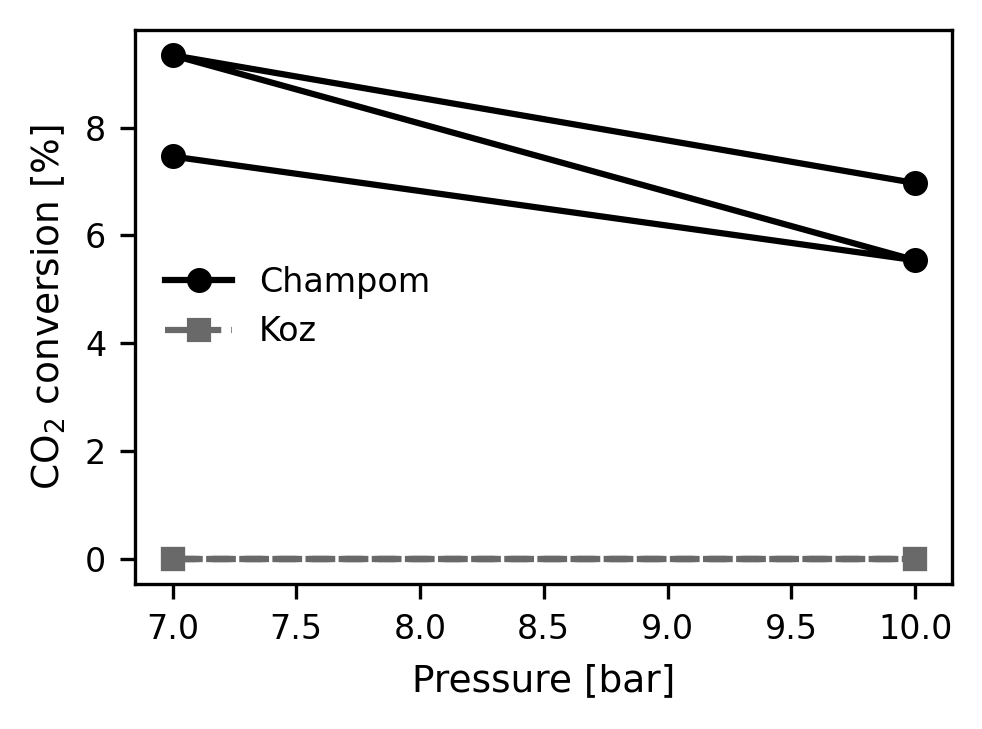

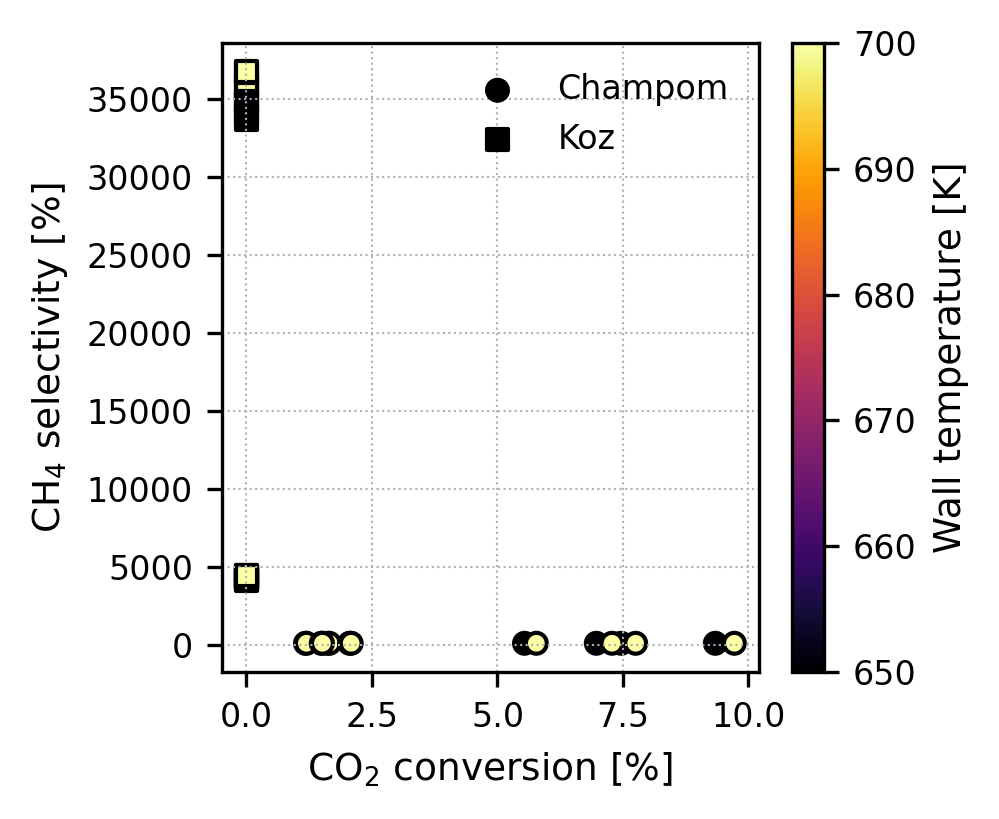

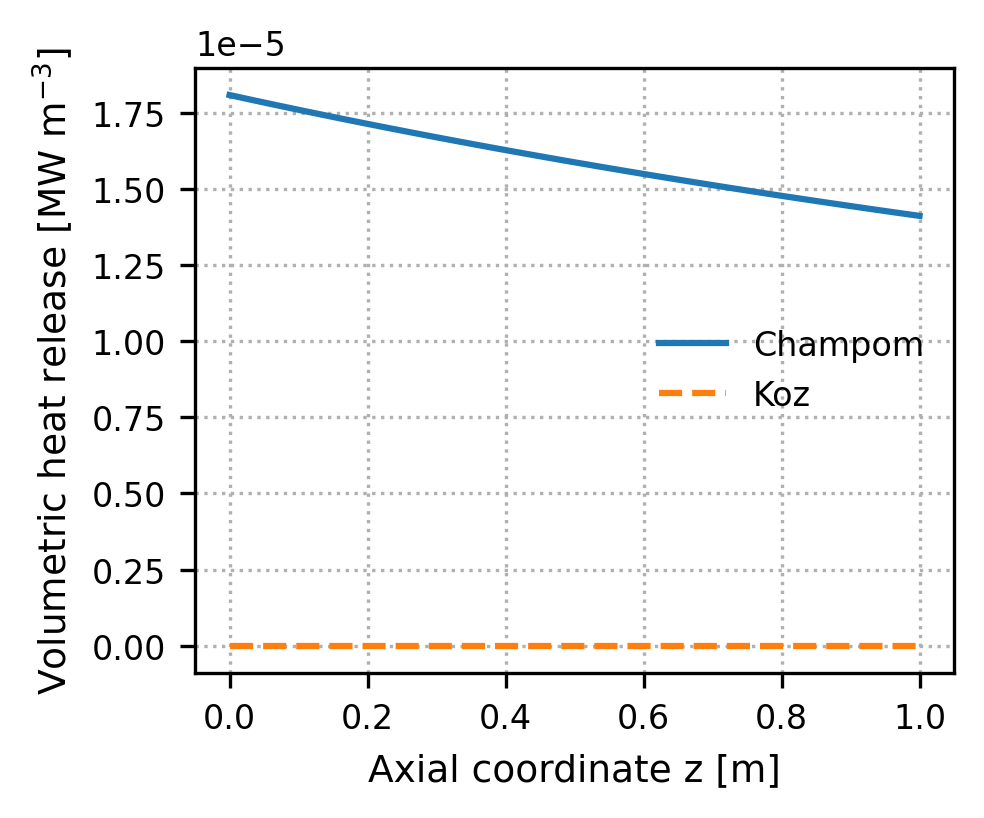

In [24]:
# ============================================================
# FULL STEADY-STATE REACTOR + PARAMETRIC + MULTI-KINETICS
# ============================================================

from fipy import *
import numpy as np
import matplotlib.pyplot as plt
from fipy.tools import numerix
import pandas as pd
from fipy.terms import ImplicitSourceTerm


def safe(x):
    return numerix.maximum(x, 1e-8)

def safe_exp(x):
    return numerix.exp(numerix.clip(x, -100, 100))

def safe_div(numer, denom, eps=1e-12):
    return numer / numerix.maximum(denom, eps)

def radial_avg(Cvar, Nr, Nz):
    """Return radial average along reactor length (axis=0 is radial)."""
    return np.mean(Cvar.reshape(Nr, Nz), axis=0)

# -----------------------------
# Global constants
# -----------------------------
R = 8.314
rho_b = 2450
eps = 0.4
Dr, Dz = 1e-5, 1e-5
lambda_e = 0.8
dH = [-165e3, 41e3, -206e3]
Tin = 600
rhoCp = 1.5e6


species = ["H2", "CO2", "CH4", "H2O", "CO"]

nu = {
    "H2":  [-4, -1, -3],
    "CO2": [-1, -1,  0],
    "CH4": [ 1,  0,  1],
    "H2O": [ 2,  1,  1],
    "CO":  [ 0,  1, -1]
}


# ============================================================
# KINETIC MODELS
# ============================================================

def champom_kinetics(p, T, k):
    T = numerix.clip(T, 300, 2000)

    kco2  = k["k0co2"]  * safe_exp(-k["eaco2"] / (R*T))
    krwgs = k["k0rwgs"] * safe_exp(-k["earwgs"] / (R*T))
    kco   = k["k0co"]   * safe_exp(-k["eaco"] / (R*T))

    Keq = 137* T**(-3.998) * safe_exp(158700/(R*T))

    Kco  = k["kads0co"]  * safe_exp(k["deltahco"]  / (R*T))
    Kh2  = k["kads0h2"]  * safe_exp(k["deltahh2"]  / (R*T))
    Kh2o = k["kads0h2o"] * safe_exp(k["deltahh2o"] / (R*T))
    Kco2 = k["kads0co2"] * safe_exp(k["deltahco2"] / (R*T))

    denom = 1 + Kh2 * p["H2"] + Kco2 * p["CO2"] + Kh2o * p["H2O"] + Kco * p["CO"]

    driving = safe_div(1 - (p["CH4"] * p["H2O"]**2) / (p["CO2"] * p["H2"]**4 * Keq), 1)
    driving = numerix.clip(driving, 0, 1)

    r1 = kco2 * Kh2 * Kco2 * p["H2"] * p["CO2"] * driving / numerix.maximum(denom**2, 1e-12)
    r2 = krwgs * p["CO2"] / numerix.maximum(denom, 1e-12)
    r3   = kco * p["CO"] * p["H2"] / numerix.maximum(denom**2, 1e-12)
    
    return [r1, r2, r3]

def koz_kinetics(p, T, k):
    T = numerix.clip(T, 300, 2000)

    kf = k["k0"] * safe_exp(-k["Ea"] / (R*T))
    Keq = 137 * T**(-3.998) * safe_exp(158700 / (R*T))

    K_OH  = numerix.exp(k["Aoh"]  + k["Boh"] / T)
    K_H2  = numerix.exp(k["Ah2"]  + k["Bh2"] / T)
    K_mix = numerix.exp(k["Amix"] + k["Bmix"] / T)

    driving = safe_div(1 - (p["CH4"] * p["H2O"]**2)/(p["CO2"] * p["H2"]**4 * Keq),1)
    driving = numerix.clip(driving,0,1)

    num = kf * p["H2"]**0.5 * p["CO2"]**0.5 * driving
    den = (1 + K_OH*(p["H2O"] / p["H2"]**0.5) + K_H2*p["H2"]**0.5 + K_mix*p["CO2"]**0.5)**2

    return safe_div(num, den), 0.0, 0.0

def run_reactor(H2_CO2, Twall, u0, Pbar, kinetics, kin_params):

    # ---- geometry
    Rr, Lz = 0.1, 1.0
    Nr, Nz = 100, 100
    mesh = CylindricalGrid2D(dr=Rr/Nr, dz=Lz/Nz, nr=Nr, nz=Nz)

    R = 8.314
    rho_b = 2450
    eps = 0.4
    Dr = 1e-5
    lambda_e = 0.8
    dH = [-165e3, 41e3, -206e3]
    Tin = 600
    rhoCp = 1.5e6

    dz = Lz / Nz
    dtau = dz / u0

    # ---- inlet
    yCO2 = 1 / (1 + H2_CO2)
    yH2  = H2_CO2 * yCO2

    Cin = {
        "CO2": Pbar * 1e5 * yCO2 / (R * Tin),
        "H2":  Pbar * 1e5 * yH2  / (R * Tin),
        "CH4": 1e-12,
        "CO":  1e-12,
        "H2O": 1e-12
    }

    # ---- variables
    C = {sp: CellVariable(mesh=mesh, value=Cin[sp], hasOld=True)
         for sp in species}
    T = CellVariable(mesh=mesh, value=Tin, hasOld=True)

    # ---- BCs
    for sp in species:
        C[sp].faceGrad.constrain(0, mesh.facesLeft)
        C[sp].faceGrad.constrain(0, mesh.facesRight)

    T.faceGrad.constrain(0, mesh.facesLeft)
    T.constrain(Twall, mesh.facesRight)

    Qaxial = []

    # ==========================================================
    # AXIAL MARCHING
    # ==========================================================
    for k in range(Nz):

        for sp in species:
            C[sp].updateOld()
        T.updateOld()

        # --- recompute kinetics at this axial plane
        p = {s: safe(C[s] * R * T / 1e5) for s in species}
        rates = kinetics(p, T, kin_params)

        # --- species equations
        for sp in species:
            Rsp = sum(nu[sp][i] * rates[i] for i in range(3))

            eq = (
                TransientTerm(var=C[sp])
                ==
                DiffusionTerm(coeff=eps * Dr, var=C[sp])
                + ImplicitSourceTerm(
                    coeff=rho_b * Rsp / (C[sp] + 1e-12),
                    var=C[sp]
                )
            )
            eq.solve(dt=dtau)

        # --- energy equation
        Qrxn = sum(-dH[i] * rates[i] for i in range(3))

        energy = (
            TransientTerm(coeff=rhoCp, var=T)
            ==
            DiffusionTerm(coeff=lambda_e, var=T)
            + ImplicitSourceTerm(
                coeff=rho_b * Qrxn / (T + 1e-6),
                var=T
            )
        )
        energy.solve(dt=dtau)

        # --- axial heat release (radial average at plane k)
        Qmat = Qrxn.value.reshape(Nz, Nr)
        Qaxial.append(Qmat[k, :].mean())

        if k % 50 == 0:
            print(f"z = {k*dz:6.3f} m | Tmax = {T.value.max():7.1f} K")

    # ==========================================================
    # OUTLET METRICS
    # ==========================================================
    CO2_out = C["CO2"].value[-Nr:].mean()
    CH4_out = C["CH4"].value[-Nr:].mean()

    X = (Cin["CO2"] - CO2_out) / Cin["CO2"]
    S = CH4_out / (Cin["CO2"] - CO2_out + 1e-12)

    return X, S, T.value, np.array(Qaxial)



# ============================================================
# PARAMETERS
# ============================================================

# ---- Champom kinetics ----
kin_champom = dict(
    k0co2=1900000, eaco2=110000,
    k0rwgs=29666.66667, earwgs=97100,
    k0co=3716666.667, eaco=97300,
    kads0co=0.00239, deltahco=40600,
    kads0h2=0.000052, deltahh2=52000,
    kads0h2o=0.609, deltahh2o=14500,
    kads0co2=1.07, deltahco2=9720
)

kin_koz = dict(
    k0=3.46e-5,
    Ea=77500,
    Aoh=0.5, Boh=-2694.25,
    Ah2=0.44, Bh2=745.73,
    Amix=0.88, Bmix=1202.79
)

ratios = [3, 4]
Twalls = [650, 700]
vels = [0.1, 0.5]
pressures = [7, 10]

# ============================================================
# PARAMETRIC SWEEP
# ============================================================

results = []

case = 0
total = len(ratios) * len(Twalls) * len(vels) * len(pressures)

for r in ratios:
    for Tw in Twalls:
        for u in vels:
            for P in pressures:
                case += 1
                print(f"▶ Case {case} / {total} | H2/CO2={r}, T={Tw}, u={u}, P={P}")

                Xc, Sc, Tc, Qaxialc = run_reactor(r, Tw, u, P,
                                     champom_kinetics, kin_champom)
                Xk, Sk, Tk, Qaxialk = run_reactor(r, Tw, u, P,
                                     koz_kinetics, kin_koz)
                results.append([r, Tw, u, P, Xc, Sc, Xk, Sk])

results = pd.DataFrame(
    results,
    columns=["H2_CO2", "Twall", "u0", "P",
             "X_champom", "S_champom", "X_Koz", "S_Koz"]
)

results

# ============================================================
# PLOTS
# ============================================================

# Convert conversion and selectivity to percent
results["X_ch_pct"] = results["X_champom"] * 100
results["X_koz_pct"] = results["X_Koz"] * 100
results["S_ch_pct"] = results["S_champom"] * 100
results["S_koz_pct"] = results["S_Koz"] * 100

# ============================================================
# JOURNAL-READY STYLE (Energy / CES)
# ============================================================

import matplotlib.pyplot as plt

COLORS = {
    "Champom": "black",
    "Koz": "dimgray"
}

MARKERS = {
    "Champom": "o",
    "Koz": "s"
}

LINESTYLES = {
    "Champom": "-",
    "Koz": "--"
}

plt.rcParams.update({
    "figure.figsize": (6.8, 5.5),   # double-column
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "lines.markersize": 5,
    "axes.grid": False,
    "figure.dpi": 300
})
def plot_sweep(ax, x, y, label):
    ax.plot(
        x,
        y,
        marker=MARKERS[label],
        linestyle=LINESTYLES[label],
        color=COLORS[label],
        label=label
    )
fig, axes = plt.subplots(2, 2, sharey=True)
axes = axes.flatten()

# (a) Pressure
sub = results[(results.Twall == 650) & (results.u0 == 0.1)]
plot_sweep(axes[0], sub.P, sub.X_ch_pct, "Champom")
plot_sweep(axes[0], sub.P, sub.X_koz_pct, "Koz")
axes[0].set_xlabel("Pressure [bar]")
axes[0].set_ylabel("CO$_2$ conversion [%]")
axes[0].set_title("(a) Pressure")

# (b) Wall temperature
sub = results[(results.P == 7) & (results.u0 == 0.1)]
plot_sweep(axes[1], sub.Twall, sub.X_ch_pct, "Champom")
plot_sweep(axes[1], sub.Twall, sub.X_koz_pct, "Koz")
axes[1].set_xlabel("Wall temperature [K]")
axes[1].set_title("(b) Temperature")

# (c) Velocity
sub = results[(results.Twall == 650) & (results.P == 7)]
plot_sweep(axes[2], sub.u0, sub.X_ch_pct, "Champom")
plot_sweep(axes[2], sub.u0, sub.X_koz_pct, "Koz")
axes[2].set_xlabel("Superficial velocity [m s$^{-1}$]")
axes[2].set_ylabel("CO$_2$ conversion [%]")
axes[2].set_title("(c) Velocity")

# Remove unused panel
fig.delaxes(axes[3])

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()
plt.figure(figsize=(3.35, 2.5))  # single-column

sub = results[(results.Twall == 700) & (results.P == 10)]

plot_sweep(plt.gca(), sub.H2_CO2, sub.X_ch_pct, "Champom")
plot_sweep(plt.gca(), sub.H2_CO2, sub.X_koz_pct, "Koz")

plt.xlabel("H$_2$/CO$_2$ ratio")
plt.ylabel("CO$_2$ conversion [%]")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()
def auto_parametric_plot(xvar, fixed, xlabel):
    plt.figure(figsize=(3.35, 2.5))

    sub = results.copy()
    for k, v in fixed.items():
        sub = sub[sub[k] == v]

    plot_sweep(plt.gca(), sub[xvar], sub.X_ch_pct, "Champom")
    plot_sweep(plt.gca(), sub[xvar], sub.X_koz_pct, "Koz")

    plt.xlabel(xlabel)
    plt.ylabel("CO$_2$ conversion [%]")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()
auto_parametric_plot(
    xvar="P",
    fixed={"Twall": 650, "u0": 0.1},
    xlabel="Pressure [bar]"
)
plt.figure(figsize=(3.35, 2.8))

plt.scatter(
    results.X_ch_pct,
    results.S_ch_pct,
    c=results.Twall,
    cmap="inferno",
    marker="o",
    edgecolor="black",
    label="Champom"
)

plt.scatter(
    results.X_koz_pct,
    results.S_koz_pct,
    c=results.Twall,
    cmap="inferno",
    marker="s",
    edgecolor="black",
    label="Koz"
)

cbar = plt.colorbar()
cbar.set_label("Wall temperature [K]")

plt.xlabel("CO$_2$ conversion [%]")
plt.ylabel("CH$_4$ selectivity [%]")

plt.legend(frameon=False)
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()


z = np.linspace(0, Lz, len(Qc))

plt.figure(figsize=(3.35, 2.8))
plt.plot(z, Qc / 1e6, label="Champom", linewidth=1.5)
plt.plot(z, Qk / 1e6, "--", label="Koz", linewidth=1.5)

plt.xlabel("Axial coordinate z [m]")
plt.ylabel("Volumetric heat release [MW m$^{-3}$]")
plt.legend(frameon=False)
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()

In [ ]:
# Reactor 2D 

from fipy import *
import numpy as np
import matplotlib.pyplot as plt
from fipy.tools import numerix
import pandas as pd
from fipy.terms import ImplicitSourceTerm

#Random equations for non-NaN results
def safe(x):
    return numerix.maximum(x, 1e-8)

def safe_exp(x):
    return numerix.exp(numerix.clip(x, -100, 100))

def safe_div(numer, denom, eps=1e-12):
    return numer / numerix.maximum(denom, eps)

def radial_avg(Cvar, Nr, Nz):
    """Return radial average along reactor length (axis=0 is radial)."""
    return np.mean(Cvar.reshape(Nr, Nz), axis=0)

#Species and their values
species = ["H2", "CO2", "CH4", "H2O", "CO"]

nu = {
    "H2":  [-4, -1, -3],
    "CO2": [-1, -1,  0],
    "CH4": [ 1,  0,  1],
    "H2O": [ 2,  1,  1],
    "CO":  [ 0,  1, -1]
}


#Kinectic Models - Champom 2019 and Koschany 2016
def champom_kinetics(p, T, k):
    T = numerix.clip(T, 300, 2000)

    kco2  = k["k0co2"]  * safe_exp(-k["eaco2"] / (R*T))
    krwgs = k["k0rwgs"] * safe_exp(-k["earwgs"] / (R*T))
    kco   = k["k0co"]   * safe_exp(-k["eaco"] / (R*T))

    Keq = 137* T**(-3.998) * safe_exp(158700/(R*T))
    Kco  = k["kads0co"]  * safe_exp(k["deltahco"]  / (R*T))
    Kh2  = k["kads0h2"]  * safe_exp(k["deltahh2"]  / (R*T))
    Kh2o = k["kads0h2o"] * safe_exp(k["deltahh2o"] / (R*T))
    Kco2 = k["kads0co2"] * safe_exp(k["deltahco2"] / (R*T))

    denom = 1 + Kh2 * p["H2"] + Kco2 * p["CO2"] + Kh2o * p["H2O"] + Kco * p["CO"]

    driving = safe_div(1 - (p["CH4"] * p["H2O"]**2) / (p["CO2"] * p["H2"]**4 * Keq), 1)
    driving = numerix.clip(driving, 0, 1)

    r1 = kco2 * Kh2 * Kco2 * p["H2"] * p["CO2"] * driving / numerix.maximum(denom**2, 1e-12)
    r2 = krwgs * p["CO2"] / numerix.maximum(denom, 1e-12)
    r3   = kco * p["CO"] * p["H2"] / numerix.maximum(denom**2, 1e-12)
    
    return [r1, r2, r3]

def koz_kinetics(p, T, k):
    T = numerix.clip(T, 300, 2000)

    kf = k["k0"] * safe_exp(-k["Ea"] / (R*T))
    
    Keq = 137 * T**(-3.998) * safe_exp(158700 / (R*T))
    K_OH  = numerix.exp(k["Aoh"]  + (k["Boh"] / T))
    K_H2  = numerix.exp(k["Ah2"]  + (k["Bh2"] / T))
    K_mix = numerix.exp(k["Amix"] + (k["Bmix"] / T))

    driving = safe_div(1 - (p["CH4"] * p["H2O"]**2)/(p["CO2"] * p["H2"]**4 * Keq),1)
    driving = numerix.clip(driving,0,1)

    num = kf * p["H2"]**0.5 * p["CO2"]**0.5 * driving
    den = (1 + K_OH*(p["H2O"] / p["H2"]**0.5) + K_H2*p["H2"]**0.5 + K_mix*p["CO2"]**0.5)**2

    return safe_div(num, den), 0.0, 0.0

#Champom kinetics Parameters
kin_champom = dict(
    k0co2=1900000, eaco2=110000,
    k0rwgs=29666.66667, earwgs=97100,
    k0co=3716666.667, eaco=97300,
    kads0co=0.00239, deltahco=40600,
    kads0h2=0.000052, deltahh2=52000,
    kads0h2o=0.609, deltahh2o=14500,
    kads0co2=1.07, deltahco2=9720
)

#Koz kinetics Parameters
kin_koz = dict(
    k0=3.46e-4,
    Ea=77500,
    Aoh=0.5, Boh=-2694.25,
    Ah2=0.44, Bh2=745.73,
    Amix=0.88, Bmix=105.846
)

#Constants / Parameters
R = 8.314
rho_b = 2450
eps = 0.4
Dr = 1e-5
lambda_e = 0.8
dH = [-165e3, 41e3, -206e3]
Tin = 600
rhoCp = 1.5e6

#Reactor
def run_reactor(H2_CO2, Twall, u0, Pbar, kinetics, kin_params):

    #Geometry of reactor and mesh
    Rr, Lz = 0.1, 1.0
    Nr, Nz = 100, 100
    mesh = CylindricalGrid2D(dr=Rr/Nr, dz=Lz/Nz, nr=Nr, nz=Nz)
    dz = Lz / Nz
    dtau = dz / u0

    #Conditions of inlet
    yCO2 = 1 / (1 + H2_CO2)
    yH2  = H2_CO2 * yCO2

    #Concentration at the beginning
    Cin = {
        "CO2": Pbar * yCO2 / (R * Tin),
        "H2":  Pbar * yH2  / (R * Tin),
        "CH4": 0,
        "CO":  0,
        "H2O": 0
    }
    
    # Conc and Temp as in the mesh
    C = {sp: CellVariable(mesh=mesh, value=Cin[sp], hasOld=True)
         for sp in species}
    
    T = CellVariable(mesh=mesh, value=Tin, hasOld=True)

    #BCs of Conc and Temp + Axial parameters
    for sp in species:
        C[sp].faceGrad.constrain(0, mesh.facesLeft)
        C[sp].faceGrad.constrain(0, mesh.facesRight)

    T.faceGrad.constrain(0, mesh.facesLeft)
    T.constrain(Twall, mesh.facesRight)

    Qaxial = []
    Tmax_axial = []

    #Axial starts
    for k in range(Nz):
        for sp in species:
            C[sp].updateOld()
        T.updateOld()

        #Recompute kinetics at this axial plane
        p = {s: safe(C[s] * R * T) for s in species}
        rates = kinetics(p, T, kin_params)
        
        #Fail-save for pressure at moment 0
        if k == 0:
            print(
            "p_H2 =", float(p["H2"].value.mean()),
            "p_CO2 =", float(p["CO2"].value.mean()),
            "r1 =", float(rates[0].value.mean())
                )

        #MB of Species
        for sp in species:
            Rsp = sum(nu[sp][i] * rates[i] for i in range(3))

            eq = (
                TransientTerm(var=C[sp])
                ==
                DiffusionTerm(coeff=eps * Dr, var=C[sp])
                + ImplicitSourceTerm(
                    coeff=rho_b * Rsp / (C[sp] + 1e-12),
                    var=C[sp]
                )
            )
            eq.solve(dt=dtau)

        #EB of Species
        Qrxn = sum(-dH[i] * rates[i] for i in range(3))

        energy = (
            TransientTerm(coeff=rhoCp, var=T)
            ==
            DiffusionTerm(coeff=lambda_e, var=T)
            + ImplicitSourceTerm(
                coeff=rho_b * Qrxn / (T + 1e-6),
                var=T
            )
        )
        energy.solve(dt=dtau)

        #Axial heat release (radial average at plane k)
        # reshape fields
        Qmat = Qrxn.value.reshape(Nz, Nr)
        Tmat = T.value.reshape(Nz, Nr)
        
        # axial averages
        Qaxial.append(Qmat[k, :].mean())
        Tmax_axial.append(Tmat[k, :].max())

        #Are we done yet?
        if k % 50 == 0:
            print(f"z = {k*dz:6.3f} m | Tmax = {T.value.max():7.1f} K")

    #Outlet conditions and information
    CO2_out = C["CO2"].value[-Nr:].mean()
    CH4_out = C["CH4"].value[-Nr:].mean()

    X = (Cin["CO2"] - CO2_out) / Cin["CO2"]
    S = CH4_out / (Cin["CO2"] - CO2_out + 1e-12)

    return X, S, T.value, np.array(Qaxial), np.array(Tmax_axial)


#The condtions that I can change
ratios = [1, 20]
Twalls = [650, 700]
vels = [0.1, 0.5]
pressures = [1, 50]

# PARAMETRIC SWEEP
results = []

case = 0
#Knowing how many combinations do we have for the kinetics HOW MANY DO WE HAVE =?
total = len(ratios) * len(Twalls) * len(vels) * len(pressures)

#The beginning of the reaction altering ratio, Tw, u and P
for r in ratios:
    for Tw in Twalls:
        for u in vels:
            for P in pressures:
                case += 1
                print(f"▶ Case {case} / {total} | H2/CO2={r}, T={Tw}, u={u}, P={P}")

                Xc, Sc, Tc, Qaxialc, Tmaxc = run_reactor(r, Tw, u, P,
                                     champom_kinetics, kin_champom)
                Xk, Sk, Tk, Qaxialk, Tmaxk = run_reactor(r, Tw, u, P,
                                     koz_kinetics, kin_koz)
                results.append([r, Tw, u, P, Xc, Sc, Xk, Sk])

#Results
results = pd.DataFrame(
    results,
    columns=["H2_CO2", "Twall", "u0", "P",
             "X_champom", "S_champom", "X_Koz", "S_Koz"]
)

results

# PLOTS

# Convert conversion and selectivity to percent
results["X_ch_pct"] = results["X_champom"] * 100
results["X_koz_pct"] = results["X_Koz"] * 100
results["S_ch_pct"] = results["S_champom"] * 100
results["S_koz_pct"] = results["S_Koz"] * 100

# Estabilising what colors I want for said kinetic
COLORS = {
    "Champom": "black",
    "Koz": "dimgray"
}

MARKERS = {
    "Champom": "o",
    "Koz": "s"
}

LINESTYLES = {
    "Champom": "-",
    "Koz": "--"
}

plt.rcParams.update({
    "figure.figsize": (6.8, 5.5),   # double-column
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "lines.markersize": 5,
    "axes.grid": False,
    "figure.dpi": 300
})
def plot_sweep(ax, x, y, label):
    ax.plot(
        x,
        y,
        marker=MARKERS[label],
        linestyle=LINESTYLES[label],
        color=COLORS[label],
        label=label
    )
fig, axes = plt.subplots(2, 2, sharey=True)
axes = axes.flatten()

#Pressure vs CO2 conversion
sub = results[(results.Twall == 650) & (results.u0 == 0.1)]
plot_sweep(axes[0], sub.P, sub.X_ch_pct, "Champom")
plot_sweep(axes[0], sub.P, sub.X_koz_pct, "Koz")
axes[0].set_xlabel("Pressure [bar]")
axes[0].set_ylabel("CO$_2$ conversion [%]")
axes[0].set_title("(a) Pressure")

#Wall temperature vs CO2 conversion
sub = results[(results.P == 7) & (results.u0 == 0.1)]
plot_sweep(axes[1], sub.Twall, sub.X_ch_pct, "Champom")
plot_sweep(axes[1], sub.Twall, sub.X_koz_pct, "Koz")
axes[1].set_xlabel("Wall temperature [K]")
axes[1].set_title("(b) Temperature")

#Velocity vs CO2 conversion
sub = results[(results.Twall == 650) & (results.P == 7)]
plot_sweep(axes[2], sub.u0, sub.X_ch_pct, "Champom")
plot_sweep(axes[2], sub.u0, sub.X_koz_pct, "Koz")
axes[2].set_xlabel("Superficial velocity [m s$^{-1}$]")
axes[2].set_ylabel("CO$_2$ conversion [%]")
axes[2].set_title("(c) Velocity")

# Remove unused panel
fig.delaxes(axes[3])

# Shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0.07, 1, 1])
plt.show()
plt.figure(figsize=(3.35, 2.5))  # single-column

sub = results[(results.Twall == 700) & (results.P == 10)]

#Ratio vs CO2 conversion
plot_sweep(plt.gca(), sub.H2_CO2, sub.X_ch_pct, "Champom")
plot_sweep(plt.gca(), sub.H2_CO2, sub.X_koz_pct, "Koz")
plt.xlabel("H$_2$/CO$_2$ ratio")
plt.ylabel("CO$_2$ conversion [%]")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

#Ratio vs CO2 conversion
def auto_parametric_plot(xvar, fixed, xlabel):
    plt.figure(figsize=(3.35, 2.5))

    sub = results.copy()
    for k, v in fixed.items():
        sub = sub[sub[k] == v]

    plot_sweep(plt.gca(), sub[xvar], sub.X_ch_pct, "Champom")
    plot_sweep(plt.gca(), sub[xvar], sub.X_koz_pct, "Koz")

    plt.xlabel(xlabel)
    plt.ylabel("CO$_2$ conversion [%]")
    plt.legend(frameon=False)
    plt.tight_layout()
    plt.show()

#Seletivity vs CO2 conversion with Twall effect
plt.scatter(
    results.X_ch_pct,
    results.S_ch_pct,
    c=results.Twall,
    cmap="inferno",
    marker="o",
    edgecolor="black",
    label="Champom"
)
plt.scatter(
    results.X_koz_pct,
    results.S_koz_pct,
    c=results.Twall,
    cmap="inferno",
    marker="s",
    edgecolor="black",
    label="Koz"
)
cbar = plt.colorbar()
cbar.set_label("Wall temperature [K]")
plt.xlabel("CO$_2$ conversion [%]")
plt.ylabel("CH$_4$ selectivity [%]")
plt.legend(frameon=False)
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

#Axial coordinate z [m] vs Volumetric heat release
z = np.linspace(0, Lz, len(Qc))

plt.figure(figsize=(3.35, 2.8))
plt.plot(z, Qc / 1e6, label="Champom", linewidth=1.5)
plt.plot(z, Qk / 1e6, "--", label="Koz", linewidth=1.5)

plt.xlabel("Axial coordinate z [m]")
plt.ylabel("Volumetric heat release [MW m$^{-3}$]")
plt.legend(frameon=False)
plt.grid(True, linestyle=":")
plt.tight_layout()
plt.show()


z = np.linspace(0, Lz, len(Qc))
fig, ax1 = plt.subplots(figsize=(3.35, 2.8))
# Heat release
ax1.plot(z, Qc / 1e6, color="black", linewidth=1.5, label="Heat release")
ax1.set_xlabel("Axial coordinate z [m]")
ax1.set_ylabel("Volumetric heat release [MW m$^{-3}$]")
# Tmax overlay
ax2 = ax1.twinx()
ax2.plot(z, Tmaxc, "--", color="firebrick", linewidth=1.5, label="T$_{max}$")
ax2.set_ylabel("Maximum temperature [K]", color="firebrick")
ax2.tick_params(axis="y", labelcolor="firebrick")
# Combined legend
lines = ax1.get_lines() + ax2.get_lines()
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, frameon=False, loc="upper right")
ax1.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()


A = np.pi * (0.1)**2  # reactor cross-section
Cin_CO2 = 7e5 * (1 / (1 + 3)) / (R * Tin)  # P=7 bar, H2/CO2=3
F_CO2 = Cin_CO2 * 0.1 * A                 # mol s⁻¹
Qnorm = Qc / F_CO2

plt.figure(figsize=(3.35, 2.8))
plt.plot(z, Qnorm / 1e3, color="black", linewidth=1.5)
plt.xlabel("Axial coordinate z [m]")
plt.ylabel("Normalized heat release [kJ mol$_{CO_2}^{-1}$ m$^{-1}$]")
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

#Tmax ao longo do radial para posição máxima de calor
k_hot = np.argmax(Tmaxc)
z_hot = z[k_hot]
Nr = 100
Nz = 100
Tmat = Tc.reshape(Nz, Nr)
r = np.linspace(0, 0.1, Nr)
T_radial = Tmat[k_hot, :]
plt.figure(figsize=(3.35, 2.8))
plt.plot(r * 1e3, T_radial, color="black", linewidth=1.5)
plt.xlabel("Radial coordinate r [mm]")
plt.ylabel("Temperature [K]")
plt.title(f"Radial profile at hotspot (z = {z_hot:.2f} m)")
plt.grid(True, linestyle=":", linewidth=0.5)
plt.tight_layout()
plt.show()

▶ Case 1 / 16 | H2/CO2=1, T=650, u=0.1, P=1
p_H2 = 0.5 p_CO2 = 0.5 r1 = 5.2210352029810294e-05


C:\Users\pingu\anaconda3\Lib\site-packages\fipy\terms\term.py:195: UserWarning: sweep() or solve() are likely to produce erroneous results when `var` does not contain floats.
  solver = self._prepareLinearSystem(var, solver, boundaryConditions, dt)
C:\Users\pingu\anaconda3\Lib\site-packages\fipy\terms\term.py:123: UserWarning: sweep() or solve() are likely to produce erroneous results when `var` does not contain floats.
  self._checkVar(var)


z =  0.000 m | Tmax =   604.0 K
z =  0.500 m | Tmax =   628.0 K
p_H2 = 0.5 p_CO2 = 0.5 r1 = 6.620476795073682e-13
z =  0.000 m | Tmax =   604.0 K
z =  0.500 m | Tmax =   629.0 K
▶ Case 2 / 16 | H2/CO2=1, T=650, u=0.1, P=50
p_H2 = 25.000000000000004 p_CO2 = 25.000000000000004 r1 = 7.653601101758427e-05
z =  0.000 m | Tmax =   604.0 K
z =  0.500 m | Tmax =   628.0 K
p_H2 = 25.000000000000004 p_CO2 = 25.000000000000004 r1 = 8.657999723325017e-13
z =  0.000 m | Tmax =   604.0 K
z =  0.500 m | Tmax =   629.0 K
▶ Case 3 / 16 | H2/CO2=1, T=650, u=0.5, P=1
p_H2 = 0.5 p_CO2 = 0.5 r1 = 5.2210352029810294e-05
z =  0.000 m | Tmax =   601.0 K
z =  0.500 m | Tmax =   602.0 K
p_H2 = 0.5 p_CO2 = 0.5 r1 = 6.620476795073682e-13
z =  0.000 m | Tmax =   601.0 K
z =  0.500 m | Tmax =   602.0 K
▶ Case 4 / 16 | H2/CO2=1, T=650, u=0.5, P=50
p_H2 = 25.000000000000004 p_CO2 = 25.000000000000004 r1 = 7.653601101758427e-05
z =  0.000 m | Tmax =   601.0 K
z =  0.500 m | Tmax =   602.0 K
p_H2 = 25.000000000000004 p

▶ Case 1 / 2 | H2/CO2=2.00, T=800.00, u=0.25, P=7.50
p_H2 = 5 p_CO2 = 2.5 r1 = 0.0001017
z =  0.000 m | Tmax =   600.0 K
z =  0.833 m | Tmax =   600.0 K
p_H2 = 5 p_CO2 = 2.5 r1 = 7.084e-13
z =  0.000 m | Tmax =   600.0 K
z =  0.833 m | Tmax =   600.0 K
▶ Case 2 / 2 | H2/CO2=2.00, T=800.00, u=0.25, P=9.00
p_H2 = 6 p_CO2 = 3 r1 = 0.0001029
z =  0.000 m | Tmax =   600.0 K
z =  0.833 m | Tmax =   600.0 K
p_H2 = 6 p_CO2 = 3 r1 = 7.155e-13
z =  0.000 m | Tmax =   600.0 K
z =  0.833 m | Tmax =   600.0 K


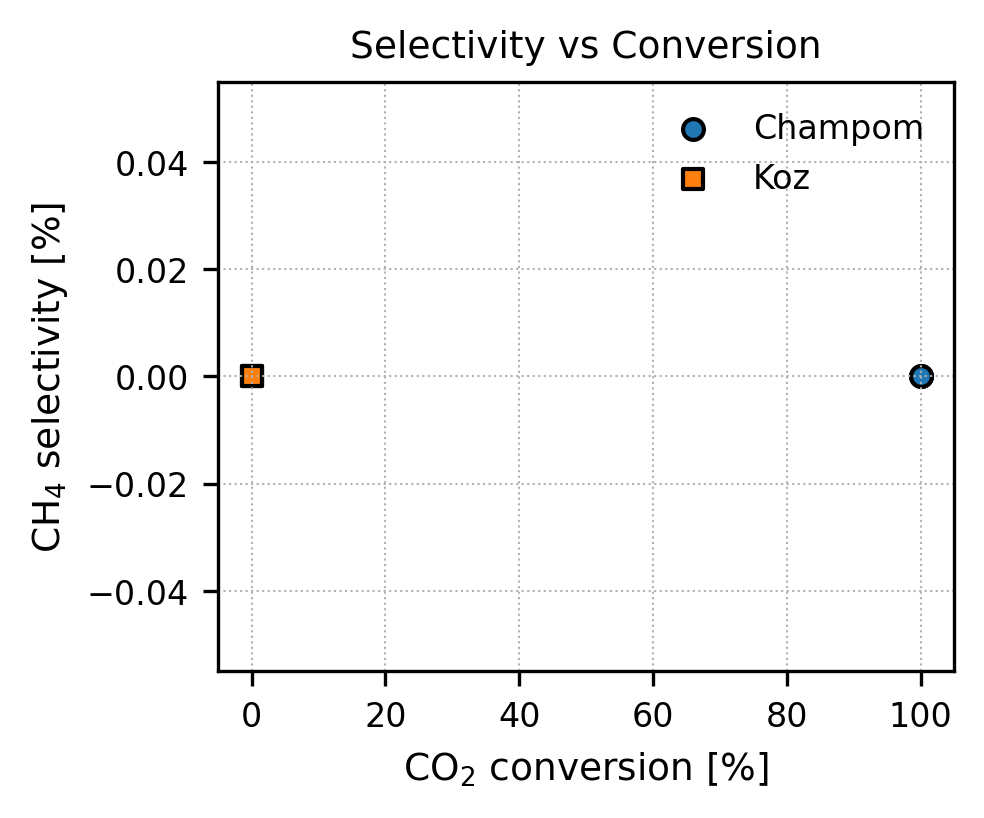

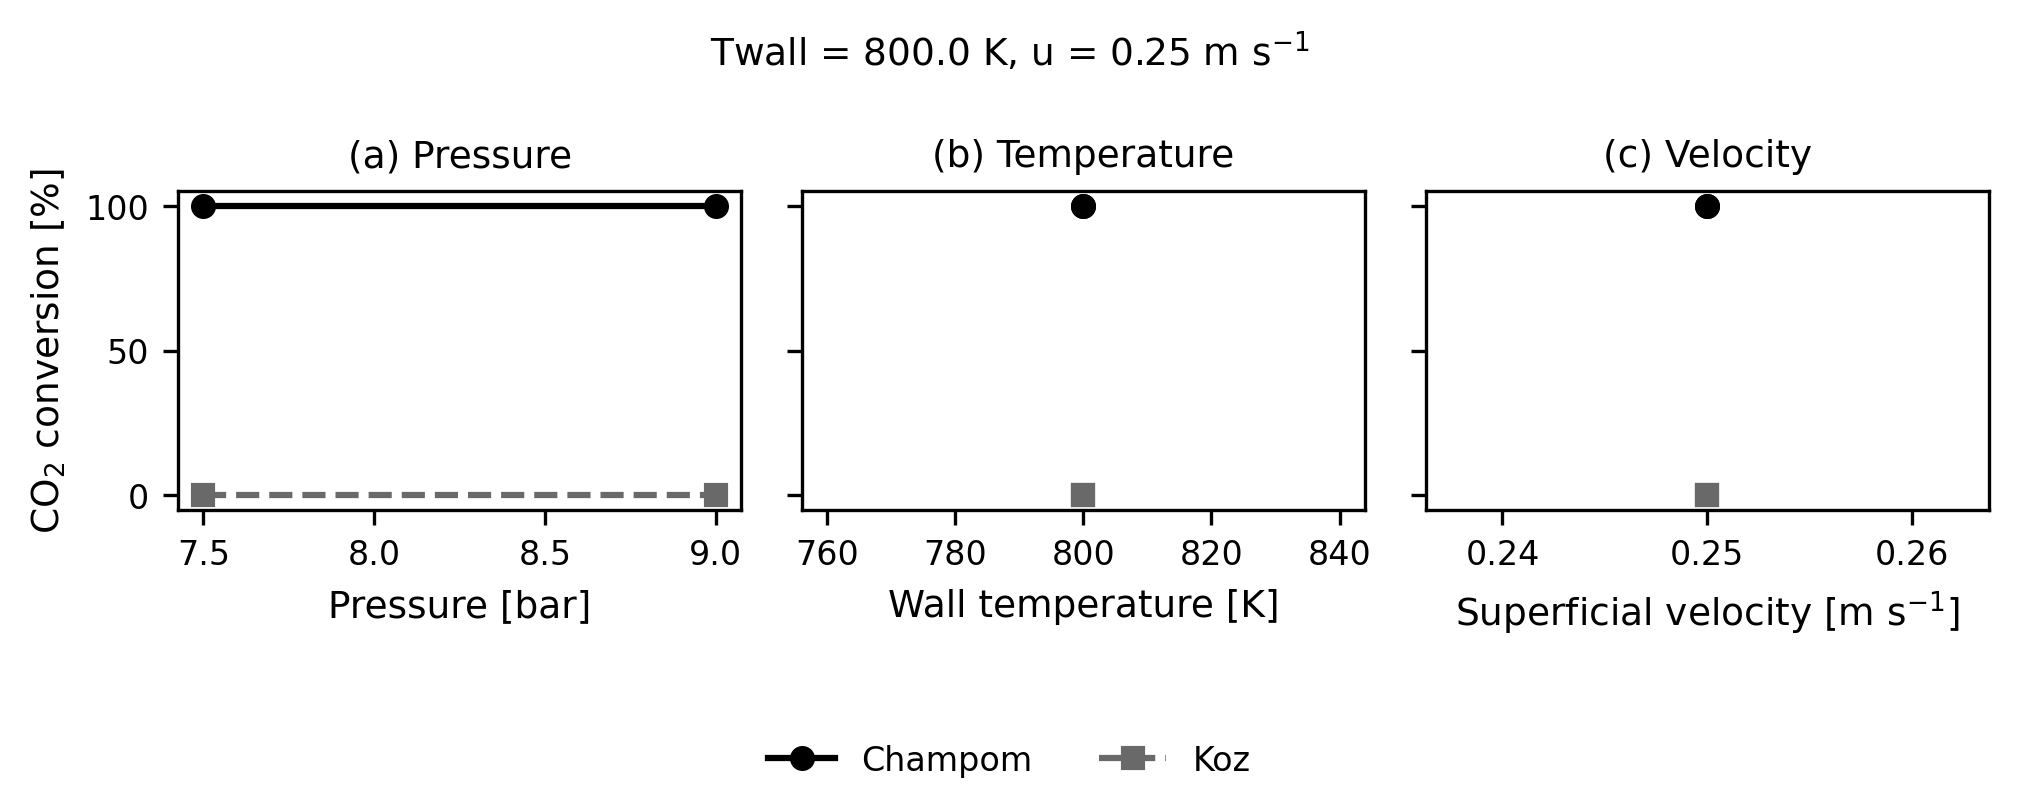

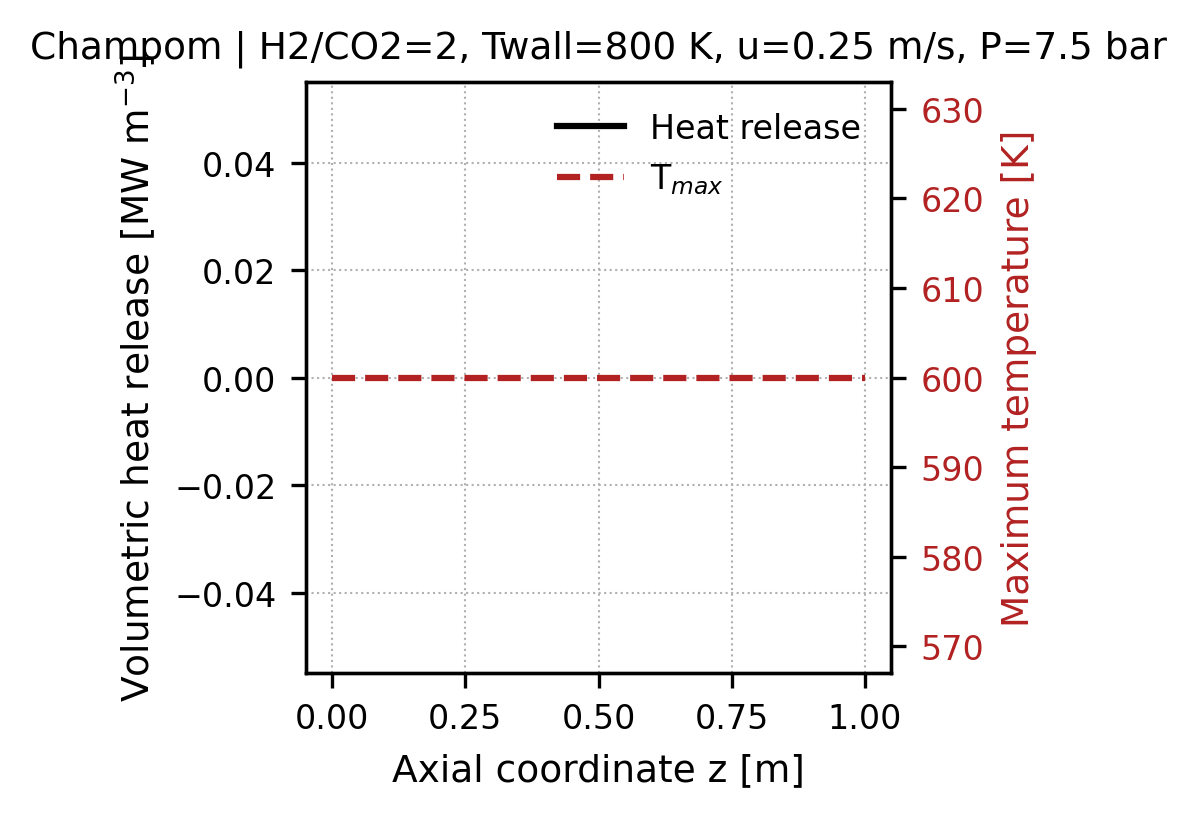

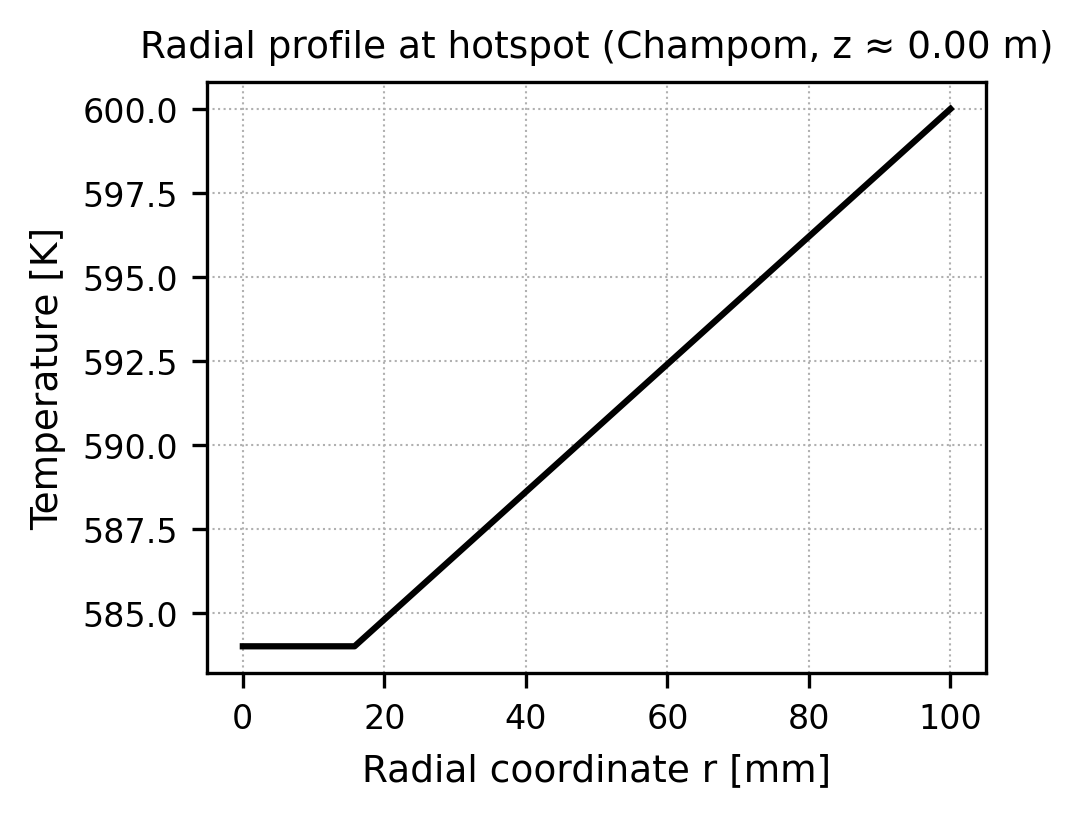

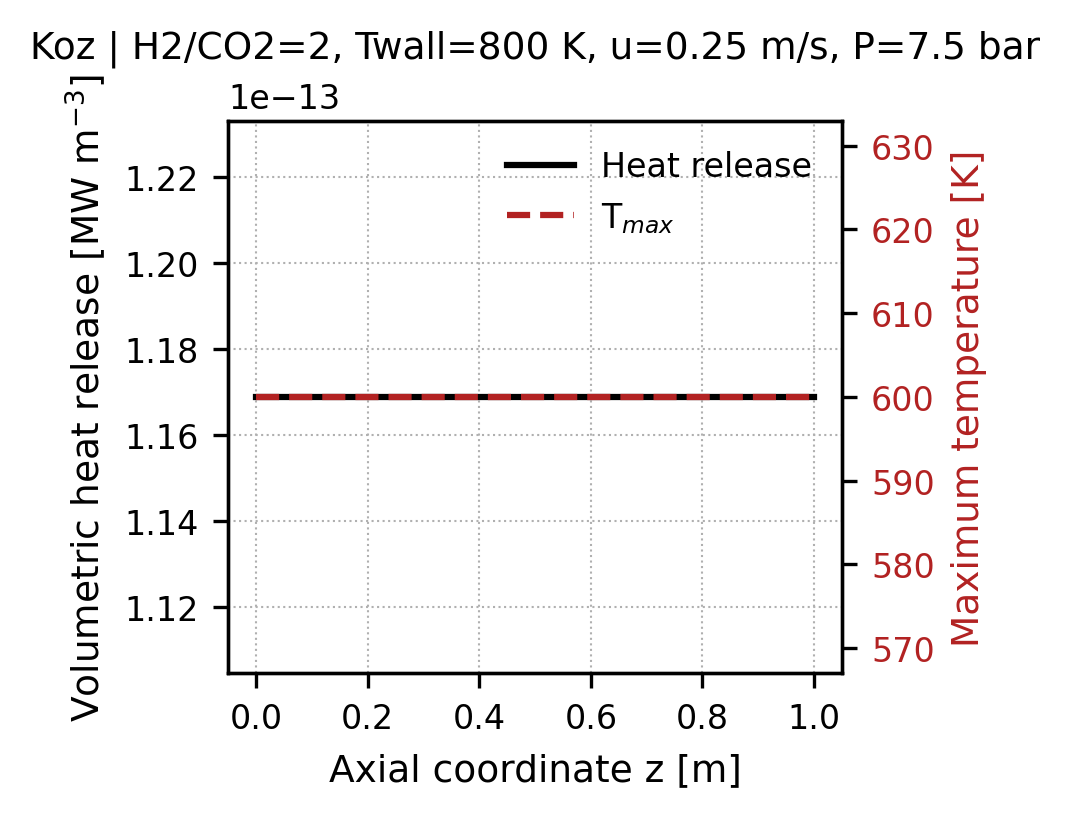

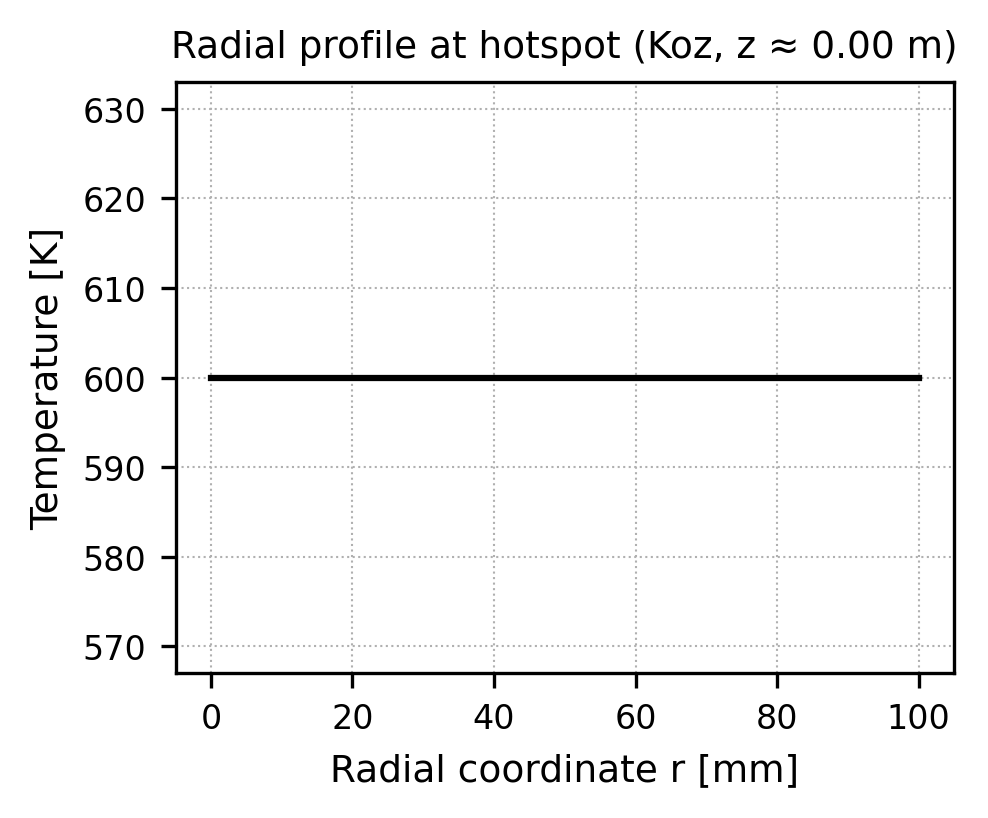

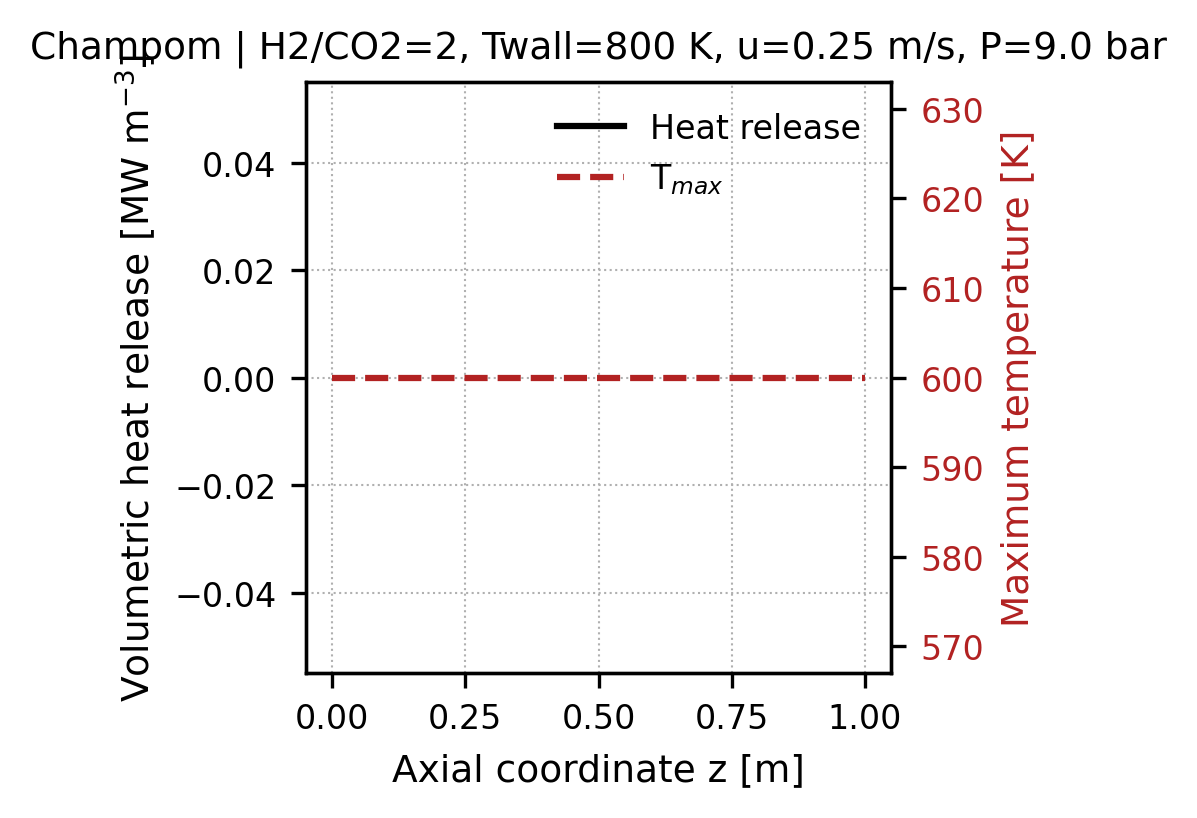

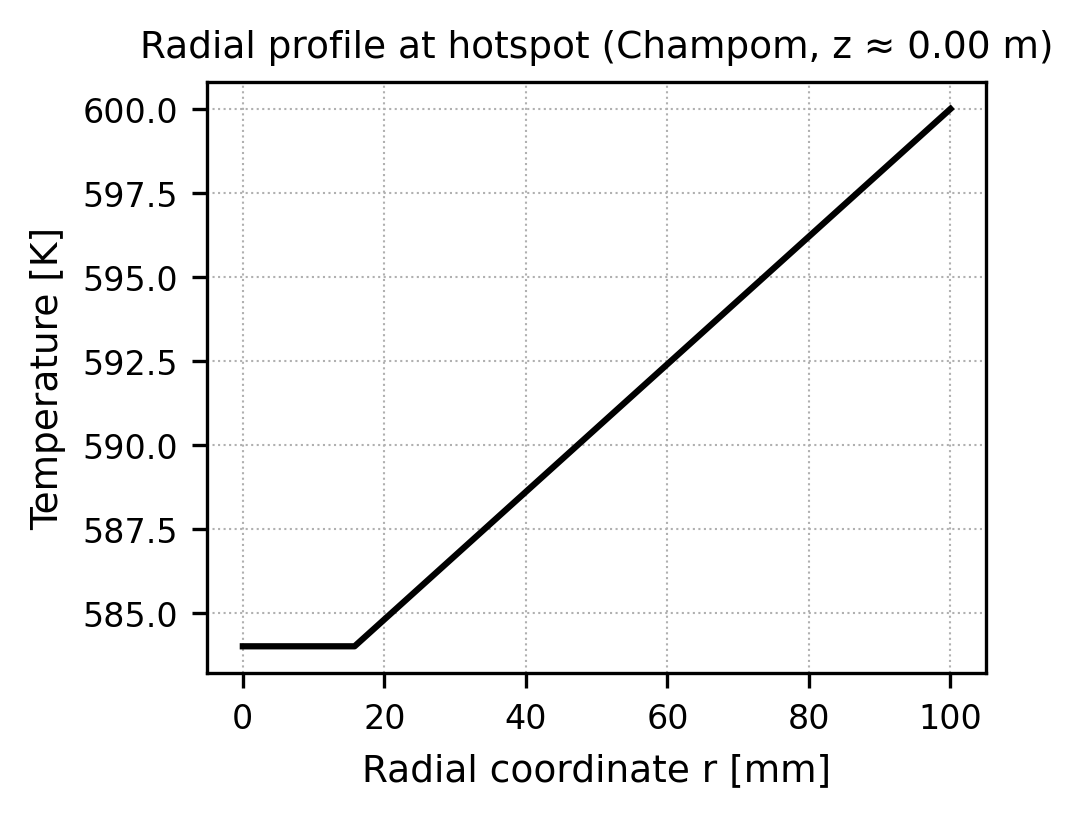

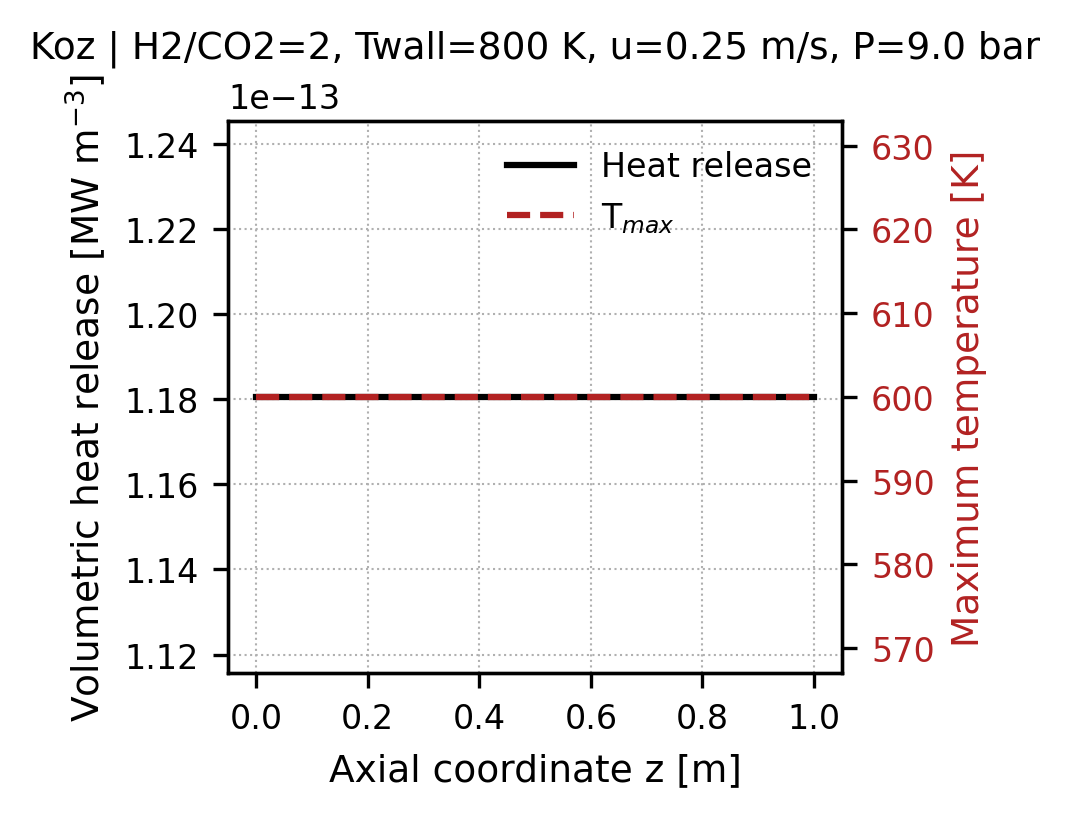

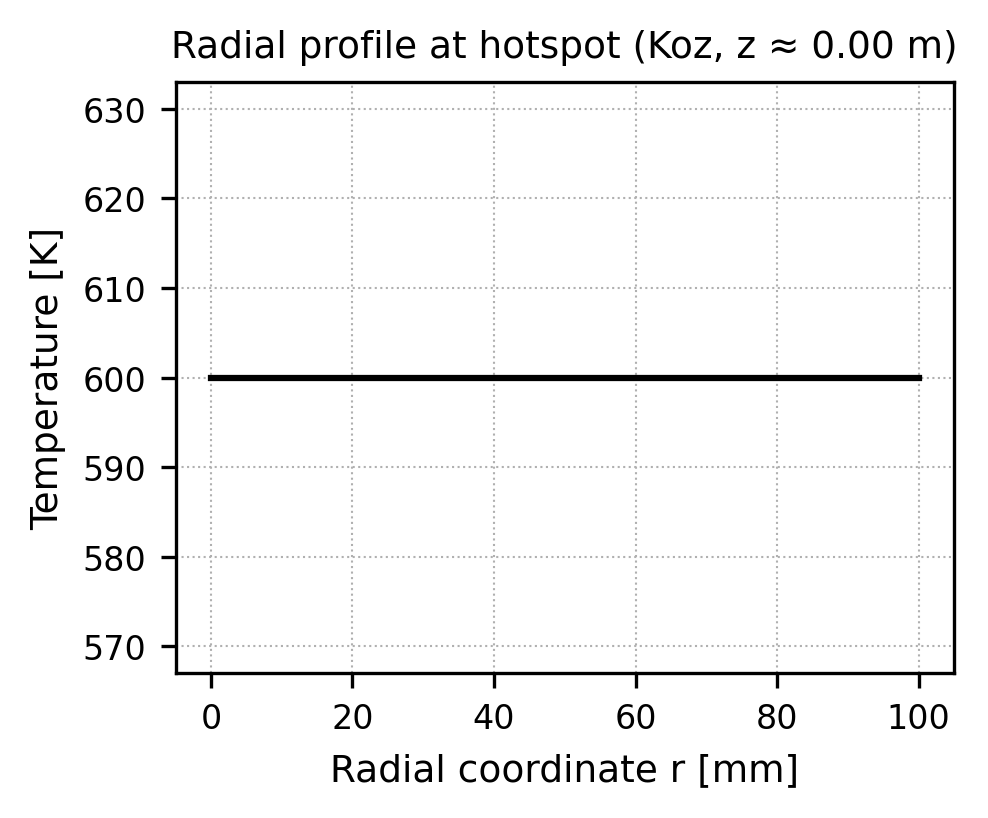

In [54]:
# Reactor 2D 

from fipy import *
import numpy as np
import matplotlib.pyplot as plt
from fipy.tools import numerix
import pandas as pd
from fipy.terms import ImplicitSourceTerm

#Random equations for non-NaN results
def safe(x):
    return numerix.maximum(x, 1e-8)

def safe_exp(x):
    return numerix.exp(numerix.clip(x, -100, 100))

def safe_div(numer, denom, eps=1e-12):
    return numer / numerix.maximum(denom, eps)

def radial_avg(Cvar, Nr, Nz):
    """Return radial average along reactor length (axis=0 is radial)."""
    return np.mean(Cvar.reshape(Nr, Nz), axis=0)

#Species and their values
species = ["H2", "CO2", "CH4", "H2O", "CO"]

nu = {
    "H2":  [-4, -1, -3],
    "CO2": [-1, -1,  0],
    "CH4": [ 1,  0,  1],
    "H2O": [ 2,  1,  1],
    "CO":  [ 0,  1, -1]
}


#Kinectic Models - Champom 2019 and Koschany 2016
def champom_kinetics(p, T, k):
    T = numerix.clip(T, 300, 2000)

    kco2  = k["k0co2"]  * safe_exp(-k["eaco2"] / (R*T))
    krwgs = k["k0rwgs"] * safe_exp(-k["earwgs"] / (R*T))
    kco   = k["k0co"]   * safe_exp(-k["eaco"] / (R*T))

    Keq = 137* T**(-3.998) * safe_exp(158700/(R*T))
    Kco  = k["kads0co"]  * safe_exp(k["deltahco"]  / (R*T))
    Kh2  = k["kads0h2"]  * safe_exp(k["deltahh2"]  / (R*T))
    Kh2o = k["kads0h2o"] * safe_exp(k["deltahh2o"] / (R*T))
    Kco2 = k["kads0co2"] * safe_exp(k["deltahco2"] / (R*T))

    denom = 1 + Kh2 * p["H2"] + Kco2 * p["CO2"] + Kh2o * p["H2O"] + Kco * p["CO"]

    driving = safe_div(1 - (p["CH4"] * p["H2O"]**2) / (p["CO2"] * p["H2"]**4 * Keq), 1)
    driving = numerix.clip(driving, 0, 1)

    r1 = kco2 * Kh2 * Kco2 * p["H2"] * p["CO2"] * driving / numerix.maximum(denom**2, 1e-12)
    r2 = krwgs * p["CO2"] / numerix.maximum(denom, 1e-12)
    r3   = kco * p["CO"] * p["H2"] / numerix.maximum(denom**2, 1e-12)
    
    return [r1, r2, r3]

def koz_kinetics(p, T, k):
    T = numerix.clip(T, 300, 2000)

    kf = k["k0"] * safe_exp(-k["Ea"] / (R*T))
    
    Keq = 137 * T**(-3.998) * safe_exp(158700 / (R*T))
    K_OH  = numerix.exp(k["Aoh"]  + (k["Boh"] / T))
    K_H2  = numerix.exp(k["Ah2"]  + (k["Bh2"] / T))
    K_mix = numerix.exp(k["Amix"] + (k["Bmix"] / T))

    driving = safe_div(1 - (p["CH4"] * p["H2O"]**2)/(p["CO2"] * p["H2"]**4 * Keq),1)
    driving = numerix.clip(driving,0,1)

    num = kf * p["H2"]**0.5 * p["CO2"]**0.5 * driving
    den = (1 + K_OH*(p["H2O"] / p["H2"]**0.5) + K_H2*p["H2"]**0.5 + K_mix*p["CO2"]**0.5)**2

    return safe_div(num, den), 0.0, 0.0

#Champom kinetics Parameters
kin_champom = dict(
    k0co2=1900000, eaco2=110000,
    k0rwgs=29666.66667, earwgs=97100,
    k0co=3716666.667, eaco=97300,
    kads0co=0.00239, deltahco=40600,
    kads0h2=0.000052, deltahh2=52000,
    kads0h2o=0.609, deltahh2o=14500,
    kads0co2=1.07, deltahco2=9720
)

#Koz kinetics Parameters
kin_koz = dict(
    k0=3.46e-4,
    Ea=77500,
    Aoh=0.5, Boh=-2694.25,
    Ah2=0.44, Bh2=745.73,
    Amix=0.88, Bmix=105.846
)

#Constants / Parameters
R = 8.314
rho_b = 2450
eps = 0.4
Dr = 1e-5
lambda_e = 0.8
dH = [-165e3, 41e3, -206e3]
Tin = 600
rhoCp = 1.5e6

#Reactor
def run_reactor(H2_CO2, Twall, u0, Pbar, kinetics, kin_params):

    #Geometry of reactor and mesh
    Rr, Lz = 0.1, 1.0
    Nr, Nz = 20, 60
    mesh = CylindricalGrid2D(dr=Rr/Nr, dz=Lz/Nz, nr=Nr, nz=Nz)
    dz = Lz / Nz
    dtau = dz / u0

    #Conditions of inlet
    yCO2 = 1 / (1 + H2_CO2)
    yH2  = H2_CO2 * yCO2

    #Concentration at the beginning
    Cin = {
        "CO2": Pbar * yCO2 / (R * Tin),
        "H2":  Pbar * yH2  / (R * Tin),
        "CH4": 0,
        "CO":  0,
        "H2O": 0
    }
    
    # Conc and Temp as in the mesh
    C = {sp: CellVariable(mesh=mesh, value=Cin[sp], hasOld=True)
         for sp in species}
    
    T = CellVariable(mesh=mesh, value=Tin, hasOld=True)

    #BCs of Conc and Temp + Axial parameters
    for sp in species:
        C[sp].faceGrad.constrain(0, mesh.facesLeft)
        C[sp].faceGrad.constrain(0, mesh.facesRight)

    T.faceGrad.constrain(0, mesh.facesLeft)
    T.constrain(Twall, mesh.facesRight)

    Qaxial = []
    Tmax_axial = []

    #Axial starts
    for k in range(Nz):
        for sp in species:
            C[sp].updateOld()
        T.updateOld()

        #Recompute kinetics at this axial plane
        p = {s: safe(C[s] * R * T) for s in species}
        rates = kinetics(p, T, kin_params)
        
        #Fail-save for pressure at moment 0
        if k == 0:
            print(
            f"p_H2 = {float(p['H2'].value.mean()):.4g}",
            f"p_CO2 = {float(p['CO2'].value.mean()):.4g}",
            f"r1 = {float(rates[0].value.mean()):.4g}"
                )

      #MB of Species
        for sp in species:
            Rsp = sum(nu[sp][i] * rates[i] for i in range(3))

            eq = (
                TransientTerm(var=C[sp])
                ==
                DiffusionTerm(coeff=eps * Dr, var=C[sp])
                + ImplicitSourceTerm(
                    coeff=rho_b * Rsp / (C[sp] + 1e-12),
                    var=C[sp]
                )
            )
            eq.solve(dt=dtau)

        #EB of Species
        Qrxn = sum(-dH[i] * rates[i] for i in range(3))

        energy = (
            TransientTerm(coeff=rhoCp, var=T)
            ==
            DiffusionTerm(coeff=lambda_e, var=T)
            + ImplicitSourceTerm(
                coeff=rho_b * Qrxn / (T + 1e-6),
                var=T
            )
        )
        energy.solve(dt=dtau)

        #Axial heat release (radial average at plane k)
        # reshape fields
        Qmat = Qrxn.value.reshape(Nz, Nr)
        Tmat = T.value.reshape(Nz, Nr)
        
        # axial averages
        Qaxial.append(Qmat[k, :].mean())
        Tmax_axial.append(Tmat[k, :].max())

        #Are we done yet?
        if k % 50 == 0:
            print(f"z = {k*dz:6.3f} m | Tmax = {T.value.max():7.1f} K")

    #Outlet conditions and information
    CO2_out = C["CO2"].value[-Nr:].mean()
    CH4_out = C["CH4"].value[-Nr:].mean()

    X = (Cin["CO2"] - CO2_out) / Cin["CO2"]
    S = CH4_out / (Cin["CO2"] - CO2_out + 1e-12)

    return X, S, T.value, np.array(Qaxial), np.array(Tmax_axial)


#The condtions that I can change
ratios = [2]
Twalls = [800]
vels = [0.25]
pressures = [7.5, 9]

# PARAMETRIC SWEEP
results = []
profiles = []
Lz = 1.0
case = 0
#Knowing how many combinations do we have for the kinetics HOW MANY DO WE HAVE =?
total = len(ratios) * len(Twalls) * len(vels) * len(pressures)

#The beginning of the reaction altering ratio, Tw, u and P
for r in ratios:
    for Tw in Twalls:
        for u in vels:
            for P in pressures:
                case += 1
                print(f"▶ Case {case} / {total} | H2/CO2={r:.2f}, T={Tw:.2f}, u={u:.2f}, P={P:.2f}")

                Xc, Sc, Tc, Qaxialc, Tmaxc = run_reactor(r, Tw, u, P,
                                     champom_kinetics, kin_champom)
                Xk, Sk, Tk, Qaxialk, Tmaxk = run_reactor(r, Tw, u, P,
                                     koz_kinetics, kin_koz)
                profiles.append({ "kinetic": "Champom","H2_CO2": r,"Twall": Tw,"u0": u,"P": P,"Qc": Qaxialc,"Tmax": Tmaxc,"Tfield": Tc})
                profiles.append({"kinetic": "Koz",
    "H2_CO2": r,
    "Twall": Tw,"u0": u,"P": P,"Qaxial": Qaxialk,"Tmax": Tmaxk,"Tfield": Tk})
                results.append([r, Tw, u, P, Xc, Sc, Xk, Sk])

#Results
profiles = pd.DataFrame(profiles)
results = pd.DataFrame(
    results,
    columns=["H2_CO2", "Twall", "u0", "P",
             "X_champom", "S_champom", "X_Koz", "S_Koz"]
)

results

# PLOTS

# Convert conversion and selectivity to percent
results["X_ch_pct"] = results["X_champom"] * 100
results["X_koz_pct"] = results["X_Koz"] * 100
results["S_ch_pct"] = results["S_champom"] * 100
results["S_koz_pct"] = results["S_Koz"] * 100

import numpy as np
import matplotlib.pyplot as plt

# --- Plot styling ---
plt.rcParams.update({
    "figure.figsize": (3.35, 2.8),
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "legend.fontsize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.linewidth": 1.5,
    "lines.markersize": 5,
    "axes.grid": False,
    "figure.dpi": 300
})

COLORS = {"Champom": "black", "Koz": "dimgray"}
MARKERS = {"Champom": "o", "Koz": "s"}
LINESTYLES = {"Champom": "-", "Koz": "--"}

# --- Generic sweep plot ---
def plot_sweep(ax, x, y, label):
    ax.plot(
        x, y,
        marker=MARKERS[label],
        linestyle=LINESTYLES[label],
        color=COLORS[label],
        label=label
    )

# --- Conversion vs Selectivity ---
def plot_selectivity_conversion(results):
    plt.figure(figsize=(3.35, 2.8))
    plt.scatter(results.X_ch_pct, results.S_ch_pct, marker="o", edgecolor="black", label="Champom")
    plt.scatter(results.X_koz_pct, results.S_koz_pct, marker="s", edgecolor="black", label="Koz")
    plt.xlabel("CO$_2$ conversion [%]")
    plt.ylabel("CH$_4$ selectivity [%]")
    plt.title("Selectivity vs Conversion")
    plt.legend(frameon=False)
    plt.grid(True, linestyle=":", linewidth=0.5)
    plt.tight_layout()
    plt.show()

# --- Conversion sweeps ---
def plot_conversion_sweeps(results):
    fixed_sets = results[["Twall", "u0"]].drop_duplicates().sort_values(["Twall", "u0"])
    for _, row in fixed_sets.iterrows():
        Tw, u = row.Twall, row.u0
        sub = results[(results.Twall == Tw) & (results.u0 == u)]
        fig, axes = plt.subplots(1, 3, figsize=(6.8, 2.6), sharey=True)

        # Pressure
        plot_sweep(axes[0], sub.P, sub.X_ch_pct, "Champom")
        plot_sweep(axes[0], sub.P, sub.X_koz_pct, "Koz")
        axes[0].set_xlabel("Pressure [bar]")
        axes[0].set_ylabel("CO$_2$ conversion [%]")
        axes[0].set_title("(a) Pressure")

        # Wall temperature
        plot_sweep(axes[1], sub.Twall, sub.X_ch_pct, "Champom")
        plot_sweep(axes[1], sub.Twall, sub.X_koz_pct, "Koz")
        axes[1].set_xlabel("Wall temperature [K]")
        axes[1].set_title("(b) Temperature")

        # Velocity
        plot_sweep(axes[2], sub.u0, sub.X_ch_pct, "Champom")
        plot_sweep(axes[2], sub.u0, sub.X_koz_pct, "Koz")
        axes[2].set_xlabel("Superficial velocity [m s$^{-1}$]")
        axes[2].set_title("(c) Velocity")

        # Shared legend
        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)
        fig.suptitle(f"Twall = {Tw} K, u = {u} m s$^{{-1}}$", fontsize=9)
        plt.tight_layout(rect=[0, 0.15, 1, 1])
        plt.show()

# --- Axial heat release and Tmax ---
def plot_axial_heat_and_T(profile, Lz=1.0):
    # Safely get Qaxial or Qc
    Q = profile.get("Qaxial")
    if Q is None:
        Q = profile.get("Qc")
    Q = np.atleast_1d(np.array(Q, dtype=float).ravel())

    Tmax = np.atleast_1d(np.array(profile["Tmax"], dtype=float).ravel())

    # Expand scalar if needed
    if Q.size == 1 and Tmax.size > 1:
        Q = np.full_like(Tmax, Q[0])
    if Tmax.size == 1 and Q.size > 1:
        Tmax = np.full_like(Q, Tmax[0])

    if len(Q) != len(Tmax):
        # If lengths mismatch, interpolate to match
        z_Q = np.linspace(0, Lz, len(Q))
        z_T = np.linspace(0, Lz, len(Tmax))
        Q = np.interp(z_T, z_Q, Q)
        z = z_T
    else:
        z = np.linspace(0, Lz, len(Q))

    fig, ax1 = plt.subplots(figsize=(3.35, 2.8))
    ax1.plot(z, Q / 1e6, color="black", linewidth=1.5, label="Heat release")
    ax1.set_xlabel("Axial coordinate z [m]")
    ax1.set_ylabel("Volumetric heat release [MW m$^{-3}$]")

    ax2 = ax1.twinx()
    ax2.plot(z, Tmax, "--", color="firebrick", linewidth=1.5, label="T$_{max}$")
    ax2.set_ylabel("Maximum temperature [K]", color="firebrick")
    ax2.tick_params(axis="y", labelcolor="firebrick")

    # Combined legend
    lines = ax1.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, frameon=False)

    title = (
        f"{profile['kinetic']} | H2/CO2={profile['H2_CO2']}, "
        f"Twall={profile['Twall']} K, u={profile['u0']} m/s, P={profile['P']} bar"
    )
    ax1.set_title(title)
    ax1.grid(True, linestyle=":", linewidth=0.5)
    plt.tight_layout()
    plt.show()


# --- Radial hotspot profile ---
def plot_radial_hotspot(profile, Rr=0.1, Nr=200, Nz=600):
    Tmax = np.atleast_1d(np.array(profile["Tmax"], dtype=float).ravel())
    Tc = np.atleast_1d(np.array(profile["Tfield"], dtype=float).ravel())

    # Ensure Tc matches expected size
    if Tc.size != Nr * Nz:
        # Resize / interpolate to match
        Tc = np.resize(Tc, (Nz * Nr))

    # Find axial index of hotspot
    k_hot = np.argmax(Tmax)
    Tmat = Tc.reshape(Nz, Nr)
    r = np.linspace(0, Rr, Nr)

    plt.figure(figsize=(3.35, 2.8))
    plt.plot(r * 1e3, Tmat[k_hot, :], color="black", linewidth=1.5)
    plt.xlabel("Radial coordinate r [mm]")
    plt.ylabel("Temperature [K]")
    plt.title(f"Radial profile at hotspot ({profile['kinetic']}, z ≈ {k_hot / Nz * Lz:.2f} m)")
    plt.grid(True, linestyle=":", linewidth=0.5)
    plt.tight_layout()
    plt.show()


# --- Full sweep of profiles ---
def plot_all_profiles(results, profiles, Lz=1.0, Rr=0.1, Nr=200, Nz=600):
    plot_selectivity_conversion(results)
    plot_conversion_sweeps(results)

    # Iterate over rows in DataFrame
    for _, row in profiles.iterrows():
        profile_dict = row.to_dict()

        # Rename "Qc" to "Qaxial" if needed
        if "Qc" in profile_dict and "Qaxial" not in profile_dict:
            profile_dict["Qaxial"] = profile_dict.pop("Qc")

        # Plot axial and radial
        plot_axial_heat_and_T(profile_dict, Lz=Lz)
        plot_radial_hotspot(profile_dict, Rr=Rr, Nr=Nr, Nz=Nz)



plot_all_profiles(results, profiles, Lz=1.0, Rr=0.1, Nr=20, Nz=60)

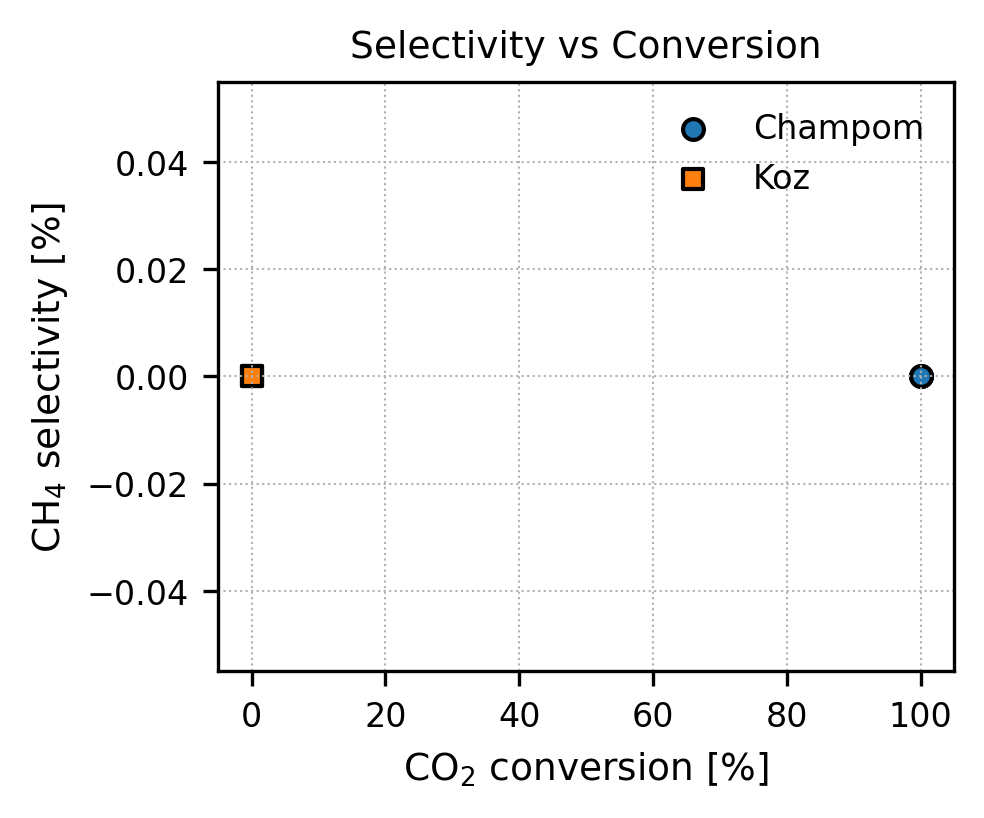

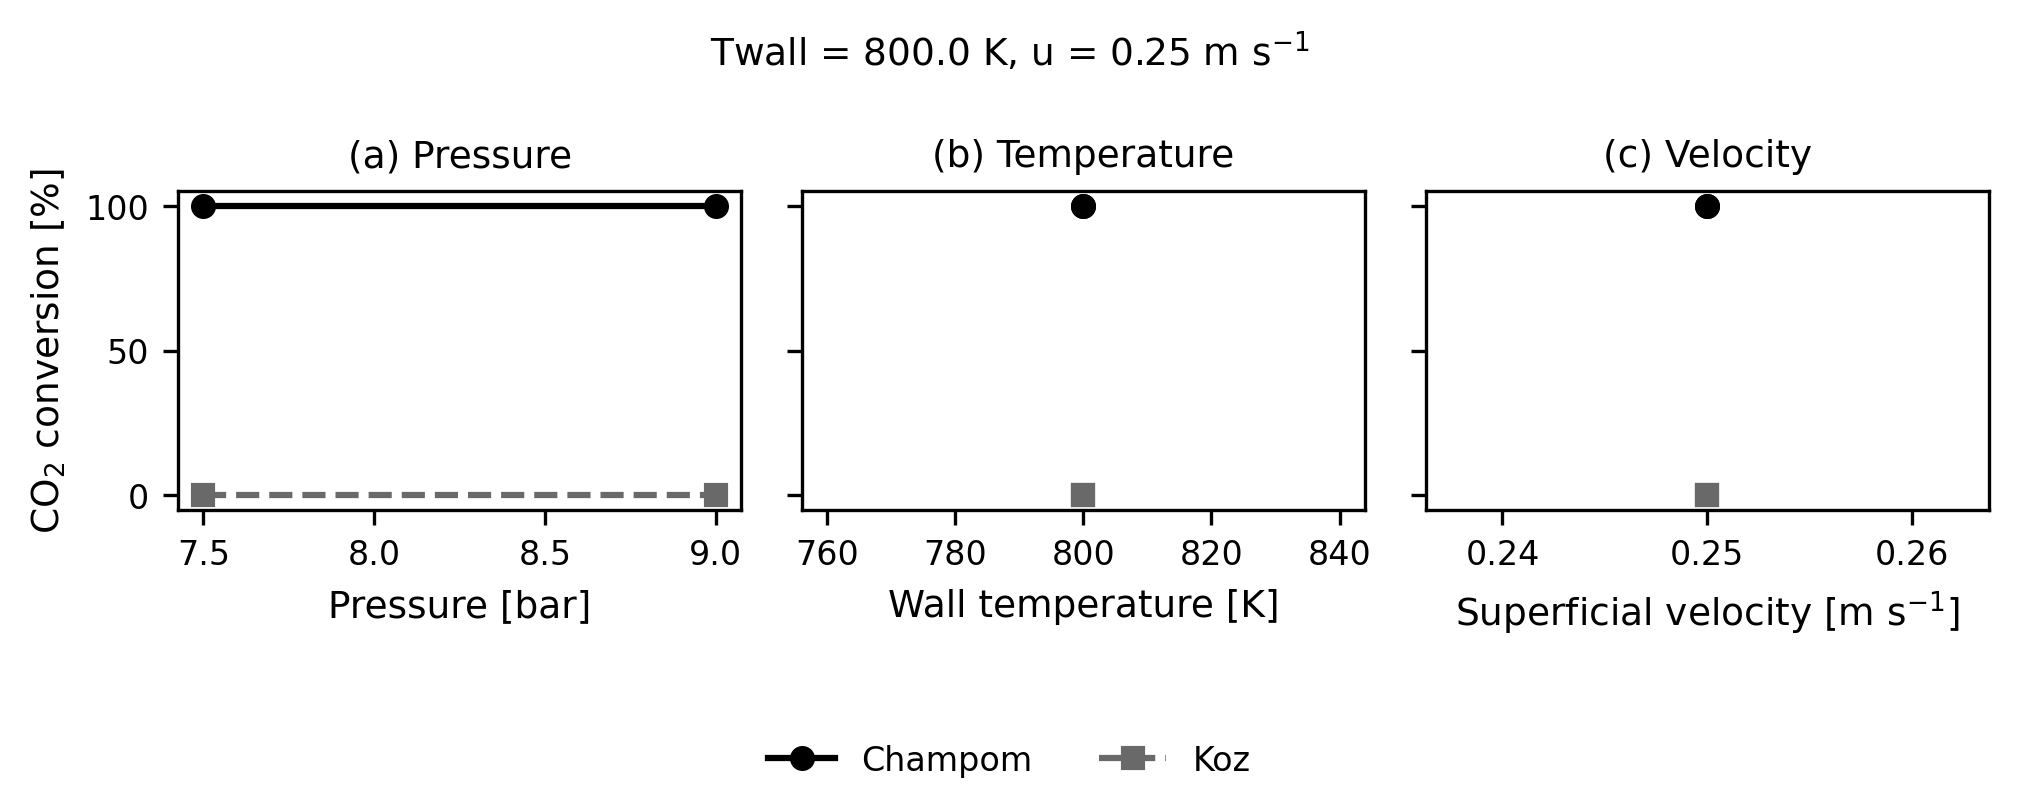

ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

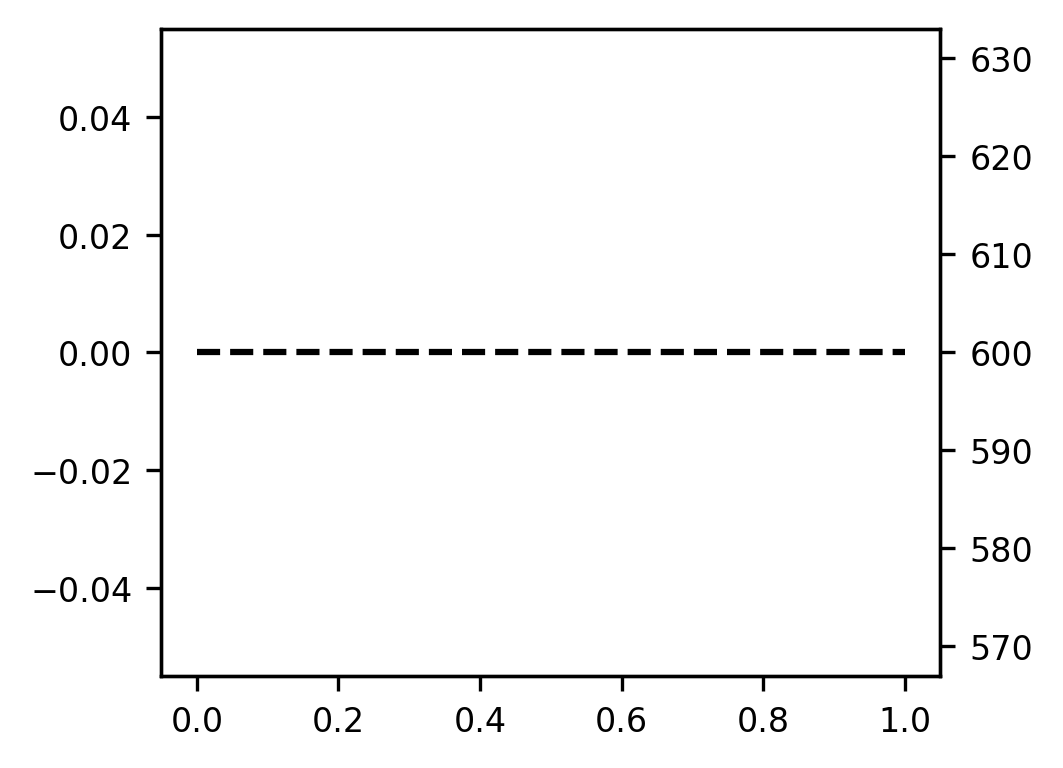

In [56]:
# Unified axial heat + Tmax plot
def plot_axial_heat_and_T_combined(profiles_list, Lz=1.0):
    fig, ax1 = plt.subplots(figsize=(3.35, 2.8))
    ax2 = ax1.twinx()

    for profile in profiles_list:
        # Safely get heat release
        Q = profile.get("Qaxial") or profile.get("Qc")
        Q = np.atleast_1d(np.array(Q, dtype=float))

        Tmax = np.atleast_1d(np.array(profile["Tmax"], dtype=float))

        # Expand scalar to match array size
        if Q.size == 1 and Tmax.size > 1:
            Q = np.full_like(Tmax, Q[0])
        elif Tmax.size == 1 and Q.size > 1:
            Tmax = np.full_like(Q, Tmax[0])

        # Interpolate if lengths still mismatch
        if len(Q) != len(Tmax):
            z_Q = np.linspace(0, Lz, len(Q))
            z_T = np.linspace(0, Lz, len(Tmax))
            Q = np.interp(z_T, z_Q, Q)
            z = z_T
        else:
            z = np.linspace(0, Lz, len(Q))

        color = COLORS[profile["kinetic"]]
        linestyle = LINESTYLES[profile["kinetic"]]

        ax1.plot(z, Q / 1e6, color=color, linestyle=linestyle, label=f"Heat ({profile['kinetic']})")
        ax2.plot(z, Tmax, "--", color=color, label=f"Tmax ({profile['kinetic']})")

    ax1.set_xlabel("Axial coordinate z [m]")
    ax1.set_ylabel("Volumetric heat release [MW/m³]")
    ax2.set_ylabel("Maximum temperature [K]")

    # Combined legend
    lines = ax1.get_lines() + ax2.get_lines()
    labels = [l.get_label() for l in lines]
    ax1.legend(lines, labels, frameon=False)

    plt.grid(True, linestyle=":", linewidth=0.5)
    plt.tight_layout()
    plt.show()


# Radial hotspot, safe for any Nr/Nz
def plot_radial_hotspot(profile, Rr=0.1, Nr=200, Nz=None):
    Tc = np.atleast_1d(np.array(profile["Tfield"], dtype=float))

    # Infer Nz if not provided
    if Nz is None:
        Nz = Tc.size // Nr

    Tmat = Tc.reshape(-1, Nr)
    Tmax_axial = Tmat.max(axis=1)
    k_hot = np.argmax(Tmax_axial)
    r = np.linspace(0, Rr, Nr)

    plt.figure(figsize=(3.35, 2.8))
    plt.plot(r*1e3, Tmat[k_hot, :], color="black", linewidth=1.5)
    plt.xlabel("Radial coordinate r [mm]")
    plt.ylabel("Temperature [K]")
    plt.title(f"Radial profile at hotspot ({profile['kinetic']}, z ≈ {k_hot/Nz:.2f} m)")
    plt.grid(True, linestyle=":", linewidth=0.5)
    plt.tight_layout()
    plt.show()


# Sweep all profiles safely
def plot_all_profiles(results, profiles, Lz=1.0, Rr=0.1, Nr=200, Nz=600):
    plot_selectivity_conversion(results)
    plot_conversion_sweeps(results)

    # Group by kinetic pairs for combined plots
    grouped_cases = profiles.groupby(["H2_CO2", "Twall", "u0", "P"])
    for _, group in grouped_cases:
        case_profiles = list(group.to_dict(orient="records"))
        plot_axial_heat_and_T_combined(case_profiles, Lz=Lz)
        for profile in case_profiles:
            plot_radial_hotspot(profile, Rr=Rr, Nr=Nr, Nz=Nz)

plot_all_profiles(results, profiles, Lz=1.0, Rr=0.1, Nr=20, Nz=60)